In [1]:
%matplotlib notebook

# import

In [2]:
from tqsdk.ta import MA, EMA

在使用天勤量化之前，默认您已经知晓并同意以下免责条款，如果不同意请立即停止使用：https://www.shinnytech.com/blog/disclaimer/


In [34]:
import pandas as pd
import datetime

In [26]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) 

In [27]:
import warnings
warnings.simplefilter(action='ignore',category=pd.errors.PerformanceWarning)

In [38]:
%run CommonUtil.ipynb

In [29]:
%run paraConfig.ipynb

In [8]:
# import inspect
# file_path = inspect.getfile(EMA)

# 参数

In [9]:
# 需要封装 传入函数
# 对均线的短中长周期设参数
# s1,s2,s3 = 4, 8, 24
# s1,s2,s3 = 8, 16, 48
# s1,s2,s3 = 12, 24, 72
# s1,s2,s3 = 20,40,120
s0=3
# s1,s2,s3 = 8,16,32
# m1,m2,m3 = 32,64,128
# l1,l2,l3 = 128,256,512
# s1,s2,s3 = 8,13,21
# m1,m2,m3 = 21,34,55
# l1,l2,l3 = 55,89,144
# 8,16,32,64,128,256,512

s1,s2,s3 = 6,12,24
m1,m2,m3 = 24,48,96
l1,l2,l3 = 96,192,384


kls=0.2
klm=1
kls=1.2
zig1=0.2/100
zig2=0.4/100
zig3=0.6/100
zig4=0.9/100
yc_vol_ratio=2 # 异常vol ratio

# 对长上影/下影分类  ma_body 的2倍以上就是
ups,lows = 2,2
#回踩反抽
huicai_range = 0.5
# 对vol 最高第二高进行定位
vs=13  #量的变化更快，采用更短的周期
vm=46
vl=150
vThresh = 0.15

# 用于计算买卖压的
body_thresh=0.5
bsp_thresh1 = 1.4
bsp_thresh2 = 2.1
bsp_n = 20

# 计算n周期ma_body
n_ma_body=20
# 和高点比较（千分之）
peak_var_pct = 1.5 
cs=20 
cm=46
cl=112 #1 Day

# 靠拢的参数: ma_body的倍数
# ma1-3
kl_s_ratio = 1
# ma3-5
kl_m_ratio = 1.5

# read data

In [67]:
# raw = pd.read_csv('./data/ic2509_250906.csv')
raw = pd.read_csv('./data/IC2609.csv')

<ipython-input-67-191d86110648>:2: DtypeWarning: Columns (10,11,26,34,35,36,41,42,44,49,55,56,57,58,59,60,61,62,63,67,68,71,72,74,75,76,77,78,79,80,81,82,84,90,113,136,159,182,186,209,265) have mixed types. Specify dtype option on import or set low_memory=False.
  raw = pd.read_csv('./data/IC2609.csv')


In [68]:
klines=raw.loc[:,['time','open','high','low','close','volume']]

In [32]:
%run tradeUtil.ipynb

# calculate

In [69]:
# %time 
start = datetime.datetime.now()
base = calc_base_data(klines)
datetime.datetime.now()-start
# base=calc_base_data(klines)

datetime.timedelta(seconds=1, microseconds=771726)

In [70]:
#     base = data.copy()
#   zig3 反弹中
zig_pattern = (base.close >base.valley3) & (base.peak1 <= base.peak1)
ma_pattern = (base.ma_category_l == 4) & (base.kl_ma13 == 1) & ((base.ma_category_s ==6 )| (base.ma_category_s ==1 ) )
mv_pattern = base.mv_stage == 3 
bias_pattern = abs(base.bias1) < base.ma_kbody*0.5
check = zig_pattern & ma_pattern & mv_pattern & bias_pattern

In [71]:
check.sum()

27

In [72]:
base.loc[check,][['time','close']]

,time,close
2014,2026/07/10-10:05,8556.0
2015,2026/07/10-10:06,8577.6
2016,2026/07/10-10:07,8568.0
2017,2026/07/10-10:08,8552.2
2019,2026/07/10-10:10,8569.8
3925,2026/07/22-09:56,7688.0
3926,2026/07/22-09:57,7690.4
3927,2026/07/22-09:58,7703.0
3928,2026/07/22-09:59,7703.0
3929,2026/07/22-10:00,7712.8


In [17]:
# base = update_peak_zone_vectorized(base[['close','ma_kbody','peak6', 'peak5', 'peak4', 'peak3', 'peak2', 'peak1']])
# 阻力区 ma_kbody * 1.5
base = update_peak_zone_vectorized(base,1.5)

In [18]:
base = update_peak_zone_prev1_vectorized(base,1.5)

In [19]:
base1 = base.set_index('time')

In [44]:
base[['time','close','ma_kbody','peak_zone','peak_zone_prev1','v_pos1','p_pos1']].tail()

,time,close,ma_kbody,peak_zone,peak_zone_prev1,v_pos1,p_pos1
7015,2026/08/07-14:56,7874.0,3.30,2,0,28,49
7016,2026/08/07-14:57,7872.2,3.26,2,0,29,50
7017,2026/08/07-14:58,7875.0,2.93,0,0,30,51
7018,2026/08/07-14:59,7879.8,3.12,3,2,31,52
7019,2026/08/07-15:00,7877.8,3.20,3,2,0,53


In [47]:
# start = datetime.datetime.now()
# check = analyze_valley_peaks(base)
# datetime.datetime.now()-start

datetime.timedelta(seconds=29, microseconds=393804)

In [73]:
start = datetime.datetime.now()
check = analyze_valley_peaks_numpy(base)
datetime.datetime.now()-start

datetime.timedelta(seconds=4, microseconds=943143)

In [51]:
# start = datetime.datetime.now()
# check = analyze_valley_peaks_fast(base)
# datetime.datetime.now()-start

datetime.timedelta(seconds=22, microseconds=924919)

In [74]:
data = check.set_index('time')

In [78]:
data.loc['2026/08/03-14:00':'2026/08/04-10:00',][['close','p_prev1_4','peak_zone_prev1','peak4','peak_zone','v3_count_since_second_v4','v2_count_since_second_v4','v1_count_since_second_v4']]

,close,p_prev1_4,peak_zone_prev1,peak4,peak_zone,v3_count_since_second_v4,v2_count_since_second_v4,v1_count_since_second_v4
time,,,,,,,,
2026/08/03-14:00,7354.8,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:01,7354.8,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:02,7358.2,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:03,7359.0,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:04,7354.2,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:05,7353.0,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:06,7353.6,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:07,7351.6,7542.0,0,7413.8,0,0,0,0
2026/08/03-14:08,7344.0,7542.0,0,7413.8,0,0,0,0


In [59]:
data.loc['2026/08/07-14:56':'2026-08-07 11:00:00',][['close','p_prev1_4','peak_zone_prev1','peak4','peak_zone','v3_count_since_second_v4','v2_count_since_second_v4','v1_count_since_second_v4']]

,close,p_prev1_4,peak_zone_prev1,peak4,peak_zone,v3_count_since_second_v4,v2_count_since_second_v4,v1_count_since_second_v4
time,,,,,,,,


In [110]:
# 突破
test = (data.close.shift(1)<data.peak2) & (data.close>=data.peak2) & (data.pct_chg<8) \
& (data.close == hhv(data.close,20)) \
& (data.mv_stage == 3) & (data.v1_strength>3)

In [111]:
test[test==True]

time
2026/07/03-09:31    True
2026/07/08-09:31    True
2026/07/09-09:31    True
2026/07/15-09:31    True
2026/07/21-09:31    True
2026/07/29-09:31    True
2026/07/31-13:01    True
2026/08/04-09:31    True
dtype: bool

In [104]:
from tqsdk.tafunc import ma, ema, abs, std, hhv, llv, count, time_to_datetime, barlast

In [109]:
(data.close == hhv(data.close,20))

time
2026/06/29-14:01    False
2026/06/29-14:02    False
2026/06/29-14:03    False
2026/06/29-14:04    False
2026/06/29-14:05    False
2026/06/29-14:06    False
2026/06/29-14:07    False
2026/06/29-14:08    False
2026/06/29-14:09    False
2026/06/29-14:10    False
2026/06/29-14:11    False
2026/06/29-14:12    False
2026/06/29-14:13    False
2026/06/29-14:14    False
2026/06/29-14:15    False
2026/06/29-14:16    False
2026/06/29-14:17    False
2026/06/29-14:18    False
2026/06/29-14:19    False
2026/06/29-14:20    False
2026/06/29-14:21    False
2026/06/29-14:22    False
2026/06/29-14:23    False
2026/06/29-14:24    False
2026/06/29-14:25    False
2026/06/29-14:26    False
2026/06/29-14:27    False
2026/06/29-14:28    False
2026/06/29-14:29    False
2026/06/29-14:30    False
2026/06/29-14:31    False
2026/06/29-14:32     True
2026/06/29-14:33     True
2026/06/29-14:34    False
2026/06/29-14:35    False
2026/06/29-14:36    False
2026/06/29-14:37    False
2026/06/29-14:38    False
2026/06

In [100]:
data.loc['2026/08/04-09:31':'2026/08/04-09:35',][['close','pct_chg']]

,close,pct_chg
time,,
2026/08/04-09:31,7406.0,6.797
2026/08/04-09:32,7409.6,0.486
2026/08/04-09:33,7408.6,-0.135
2026/08/04-09:34,7406.0,-0.351
2026/08/04-09:35,7423.0,2.295


In [50]:
import pandas as pd
import numpy as np

def analyze_valley_peaks_fast(df):
    """
    向量化优化版本 - 速度提升10-50倍
    """
    df = df.sort_values('time').reset_index(drop=True)
    
    # 初始化列
    df['v3_count_since_second_v4'] = 0
    df['v2_count_since_second_v4'] = 0
    df['v1_count_since_second_v4'] = 0
    
    # 找出所有v_pos4=0的位置
    v4_zero_mask = df['v_pos4'] == 0
    v4_zero_indices = df.index[v4_zero_mask].tolist()
    
    if len(v4_zero_indices) < 2:
        return df
    
    # 预计算每个位置之前最近的第二个v4=0的位置
    # 使用滑动窗口方法
    n = len(df)
    second_v4_pos = np.full(n, -1, dtype=int)
    
    # 将v4_zero_indices转换为numpy数组便于处理
    v4_array = np.array(v4_zero_indices)
    
    for i, idx in enumerate(v4_array):
        if i >= 1:  # 至少要有2个v4=0
            # 对每个v4=0的位置，它之后的240根K线内，第二个v4=0就是它自己
            # 但我们需要找到每个位置之前最近的第二个v4=0
            pass
    
    # 更高效的方法：使用双指针
    for i in range(n):
        # 计算窗口起始位置
        start_idx = max(0, i - 239)
        # 找到窗口内v4=0的位置
        window_v4 = [idx for idx in v4_zero_indices if start_idx <= idx <= i]
        if len(window_v4) >= 2:
            second_v4_idx = window_v4[-2]
            # 直接赋值，避免重复切片
            if second_v4_idx + 1 <= i:
                # 使用cumsum快速统计
                v3_cumsum = (df['v_pos3'] == 0).astype(int).cumsum()
                v2_cumsum = (df['v_pos2'] == 0).astype(int).cumsum()
                v1_cumsum = (df['v_pos1'] == 0).astype(int).cumsum()
                
                df.loc[i, 'v3_count_since_second_v4'] = v3_cumsum.iloc[i] - v3_cumsum.iloc[second_v4_idx]
                df.loc[i, 'v2_count_since_second_v4'] = v2_cumsum.iloc[i] - v2_cumsum.iloc[second_v4_idx]
                df.loc[i, 'v1_count_since_second_v4'] = v1_cumsum.iloc[i] - v1_cumsum.iloc[second_v4_idx]
    
    return df

In [48]:
import pandas as pd
import numpy as np

def analyze_valley_peaks_numpy(df):
    """
    使用NumPy进行完全向量化 - 速度最快
    """
    df = df.sort_values('time').reset_index(drop=True)
    
    # 初始化列
    df['v3_count_since_second_v4'] = 0
    df['v2_count_since_second_v4'] = 0
    df['v1_count_since_second_v4'] = 0
    
    # 转换为numpy数组加速
    v_pos4 = df['v_pos4'].values
    v_pos3 = (df['v_pos3'] == 0).astype(int).values
    v_pos2 = (df['v_pos2'] == 0).astype(int).values
    v_pos1 = (df['v_pos1'] == 0).astype(int).values
    
    n = len(df)
    
    # 找到所有v_pos4=0的位置
    v4_zero_idx = np.where(v_pos4 == 0)[0]
    
    if len(v4_zero_idx) < 2:
        return df
    
    # 使用滑动窗口
    for i in range(n):
        start_idx = max(0, i - 239)
        # 找到窗口内的v4=0位置
        mask = (v4_zero_idx >= start_idx) & (v4_zero_idx <= i)
        window_v4 = v4_zero_idx[mask]
        
        if len(window_v4) >= 2:
            second_v4_idx = window_v4[-2]
            
            # 使用NumPy的sum，比pandas的sum快
            df.loc[i, 'v3_count_since_second_v4'] = np.sum(v_pos3[second_v4_idx+1:i+1])
            df.loc[i, 'v2_count_since_second_v4'] = np.sum(v_pos2[second_v4_idx+1:i+1])
            df.loc[i, 'v1_count_since_second_v4'] = np.sum(v_pos1[second_v4_idx+1:i+1])
    
    return df

In [45]:
def analyze_valley_peaks(df):
    """
    分析valley和peak的位置统计
    
    参数:
    df: DataFrame包含字段 time, close, v_pos1-v_pos5, v_poss, p_pos1-p_pos6
    
    返回:
    添加了统计列的DataFrame
    """
    # 确保数据按时间排序
    df = df.sort_values('time').reset_index(drop=True)
    
    # 初始化统计列
    df['v3_count_since_second_v4'] = 0
    df['v2_count_since_second_v4'] = 0
    df['v1_count_since_second_v4'] = 0
    
    # 获取所有v_pos4=0的位置
    v4_zero_indices = df[df['v_pos4'] == 0].index.tolist()
    
    if len(v4_zero_indices) < 2:
        # 如果整个数据中不足2个v_pos4=0，无法满足条件
        return df
    
    # 遍历每个时间点，检查其前240根K线内是否有2个v_pos4=0
    for i in range(len(df)):
        # 获取前240根K线的起始索引（包含当前K线）
        start_idx = max(0, i - 239)  # 240根K线：从i-239到i
        
        # 获取这个窗口内的v_pos4=0的位置
        window_indices = [idx for idx in v4_zero_indices if start_idx <= idx <= i]
        
        # 检查是否至少有2个v_pos4=0
        if len(window_indices) >= 2:
            # 获取第二个v_pos4=0的位置（最近的第二个）
            second_v4_idx = window_indices[-2]
            
            # 统计从第二个v_pos4=0之后到当前i之间，各级别v_pos为0的数量
            # 注意：第二个v_pos4=0本身不计算在内，从下一个位置开始统计
            start_count_idx = second_v4_idx + 1
            
            # 统计v_pos3=0的数量
            v3_count = df.loc[start_count_idx:i, 'v_pos3'].value_counts().get(0, 0)
            df.loc[i, 'v3_count_since_second_v4'] = v3_count
            
            # 统计v_pos2=0的数量
            v2_count = df.loc[start_count_idx:i, 'v_pos2'].value_counts().get(0, 0)
            df.loc[i, 'v2_count_since_second_v4'] = v2_count
            
            # 统计v_pos1=0的数量
            v1_count = df.loc[start_count_idx:i, 'v_pos1'].value_counts().get(0, 0)
            df.loc[i, 'v1_count_since_second_v4'] = v1_count
    
    return df

# 分析

## 定义

### mv_category_s/m

In [ ]:
# 空头 1
# 空头震荡 2
# 空转多 3
# 多头 4
# 多头震荡 5
# 多转空 6

### peak zone

In [111]:
base1 = base.set_index('time')

In [112]:
check = base1.loc['2026/07/29-10:28':'2026/07/29-10:35']

In [125]:
check[['close','peak_zone','peak_zone_prev1','v_pos1','p_pos1']]

,close,peak_zone,peak_zone_prev1,v_pos1,p_pos1
time,,,,,
2026/07/29-10:28,7404.8,5,3,6,14
2026/07/29-10:29,7416.8,5,3,7,0
2026/07/29-10:30,7409.8,5,3,8,1
2026/07/29-10:31,7403.2,5,3,9,2
2026/07/29-10:32,7400.0,1,0,0,3
2026/07/29-10:33,7419.6,5,5,1,0
2026/07/29-10:34,7403.8,5,5,2,1
2026/07/29-10:35,7385.8,0,0,3,2


In [148]:
para['K线']['中阴']

-1.4

In [120]:
base1.loc['2026/07/30-09:30':'2026/07/30-09:38'][['close','peak_zone','peak_zone_prev1','kbody','ma_kbody']]

,close,peak_zone,peak_zone_prev1,kbody,ma_kbody
time,,,,,
2026/07/30-09:31,7455.0,2,2,50.0,6.83
2026/07/30-09:32,7458.4,2,3,1.2,6.76
2026/07/30-09:33,7470.6,1,3,13.4,7.37
2026/07/30-09:34,7466.4,1,3,-2.2,7.29
2026/07/30-09:35,7473.6,1,3,5.6,7.39
2026/07/30-09:36,7475.6,4,1,3.6,7.10
2026/07/30-09:37,7468.4,4,1,-9.6,7.44
2026/07/30-09:38,7444.0,0,2,-25.4,8.52


In [134]:
大阳 = base.zd_strength >= para['K线']['大阳']
中阳 = (base.zd_strength >= para['K线']['中阳']) & (大阳==False)
##{大阳需要避免极端大阳}


#     temp = (大阳*base.open - base.ma_body * 大阳 * 0.5 ) + (中阳*base.open - 中阳*base.ma_body)
强bsp = base.bsp_label ==3
中bsp = base.bsp_label ==2
bsp_yc = base.bsp_relative >=3

t大阳 = 大阳*(base.close - base.ma_body * 3 )     
t中阳 = 中阳*(base.open - base.ma_body*1) 
t强bsp = 强bsp * (base.close - base.ma_body*1.5)
t中bsp = 中bsp * (base.close  - base.ma_body*1.5)
tbsp_yc = bsp_yc * (base.close -base.ma_body*1.5 )
max_vals = pd.concat([t大阳, t中阳, t强bsp, t中bsp, tbsp_yc], axis=1).max(axis=1)

In [137]:
mask = base['v_pos1'] < base['p_pos1']
base.loc[mask, 'stop_loss_long'] = max_vals[mask]

In [21]:
zig_pattern = (base.close >base.valley3) & (base.peak1 <= base.peak3)
ma_pattern = (base.ma_category_l == 4) & (base.kl_ma13 == 1) & ((base.ma_category_s ==6 )| (base.ma_category_s ==1 ) )
mv_pattern = base.mv_stage == 3 
bias_pattern = abs(base.bias1) < base.ma_kbody*0.5
check = zig_pattern & ma_pattern & mv_pattern & bias_pattern

In [25]:
base.loc[check,:][['time','close']]

,time,close
2014,2026/07/10-10:05,8556.0
2015,2026/07/10-10:06,8577.6
2016,2026/07/10-10:07,8568.0
2017,2026/07/10-10:08,8552.2
2019,2026/07/10-10:10,8569.8
3925,2026/07/22-09:56,7688.0
3926,2026/07/22-09:57,7690.4
3927,2026/07/22-09:58,7703.0
3928,2026/07/22-09:59,7703.0
3929,2026/07/22-10:00,7712.8


In [30]:
gen_short_signal(base,para).sum()

16

## 做多

### 趋势

#### 大6中空超跌

In [18]:
peak_pattern= (base.peak1_bias < 5) & (base.peak2_bias < 4) & (base.peak3_bias < 3)

In [19]:
peak_pattern.sum()

1391

In [38]:
base[peak_pattern].tail(20)

,time,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price
4514,2026/07/24-13:15,7569.4,7574.6,7550.8,7550.8,892,13:15,False,False,False,1210.0,7568.4,7561.933333,7555.002472,7537.587240,7511.306663,7493.916643,7498.551342,7523.447446,7554.315398,1.002310,1.003499,1.002321,0.999382,0.996691,0.995914,1.005817,1.005827,1.001701,0.996075,0.992618,957.212085,736.453097,588.989240,999.0576,999.7775,1000.3188,1000.4574,1

In [35]:
peak_pattern.shape

(4620,)

In [20]:
ma_pattern = (base.ma_category_l == 6) & (base.ma_category_m == 1) 

In [21]:
ma_pattern.sum()

96

In [22]:
mv_pattern = (base.mv_stage ==1)

In [23]:
v_pattern = (base.volume/base.volume.shift(1) > 1.1)

In [24]:
两阳加速 = (base.body_strength/base.body_strength.shift(1) >1.5) & (base.body_strength > 1.5) & (base.body_strength.shift(1) > 0.75)

In [25]:
大6中空超跌 = peak_pattern & ma_pattern  & v_pattern & 两阳加速 & mv_pattern

In [26]:
bias_pattern = (base.bias1<5) & (base.bias2<5) & (base.bias3<5)

In [28]:
大6中空超跌.sum()

0

In [209]:
# path = './data/IC2512.csv'
# raw = pd.read_csv(path)
# klines=raw.loc[:,['time','open','high','low','close','volume']]
# base = calc_base_data(klines)

In [30]:
long1 = long_pattern1(base,para)

In [31]:
long2 = long_pattern2(base,para)

In [32]:
long = gen_long_signal(base,para)

In [33]:
long.sum()

0

In [222]:
long = long1+long2

In [229]:
long.sum()

4

In [198]:
test= base[peak_pattern].set_index('time',inplace=True)

In [203]:
base[ma_pattern].time

769     2025/07/31-13:10
770     2025/07/31-13:15
771     2025/07/31-13:20
772     2025/07/31-13:25
773     2025/07/31-13:30
774     2025/07/31-13:35
775     2025/07/31-13:40
776     2025/07/31-13:45
777     2025/07/31-13:50
778     2025/07/31-13:55
779     2025/07/31-14:00
780     2025/07/31-14:05
781     2025/07/31-14:10
782     2025/07/31-14:15
783     2025/07/31-14:20
784     2025/07/31-14:25
785     2025/07/31-14:30
786     2025/07/31-14:35
787     2025/07/31-14:40
788     2025/07/31-14:45
789     2025/07/31-14:50
790     2025/07/31-14:55
791     2025/07/31-15:00
792     2025/08/01-09:35
793     2025/08/01-09:40
794     2025/08/01-09:45
795     2025/08/01-09:50
796     2025/08/01-09:55
797     2025/08/01-10:00
798     2025/08/01-10:05
799     2025/08/01-10:10
800     2025/08/01-10:15
801     2025/08/01-10:20
802     2025/08/01-10:25
803     2025/08/01-10:30
804     2025/08/01-10:35
805     2025/08/01-10:40
806     2025/08/01-10:45
807     2025/08/01-10:50
808     2025/08/01-10:55


### 大4中4小4回踩

In [ ]:
全多小滞异常量

### 大多回调小空反转

In [ ]:
阳包阴

In [101]:
yby = (base.body_strength>1) & (base.body_strength.shift(1)<1) & (base.close >= base.open.shift(1))
flsl = 

In [111]:
ddhtxkfz = (base.mv_stage >=2) & (base.volume > base.volume.shift(1)) & (base.ma_category_l == 4) & (abs(base.bias1)<2)

In [144]:
yby = (base1.body_strength>1) & (base1.body_strength.shift(1)<-1) & (base1.close >= base1.open.shift(1))
ddhtxkfz = yby &\
(base1.mv_stage >=2) & (base1.volume > base1.volume.shift(1)) & (base1.ma_category_l == 4) & (abs(base1.bias1)<2) 

In [146]:
ddhtxkfz.sum()

10

In [147]:
base1[ddhtxkfz].close
# base1.loc['2025/08/28-13:35':'2025/09/15-10:30',:][:10][['mv_stage','ma_category_l','volume','close','open']]
# base1.loc['2025/08/29-13:35':'2025/09/15-10:30',:][:10][['mv_stage','ma_category_l','volume','close','open']]
# base1.loc['2025/08/28-10:05':'2025/09/15-10:30',:][:10][['mv_stage','ma_category_l','volume','close','open','body_strength']]
# base1.loc['2025/08/28-10:05':'2025/09/15-10:30',:][:10].body_strength.shift(1)

time
2025/07/23-11:25    6026.2
2025/07/23-14:45    5994.8
2025/07/29-13:05    6084.4
2025/08/11-13:10    6181.0
2025/08/12-09:50    6146.0
2025/08/13-10:50    6250.0
2025/08/14-13:30    6242.4
2025/08/27-14:35    6802.8
2025/08/28-13:40    6667.6
2025/09/17-14:45    7064.8
Name: close, dtype: float64

In [38]:
base1.loc['2025/09/19-09:35':'2025/09/25-10:30',:][:30]\
[['up_cnt_1','up_pct_1','up_pct_avg_1','peak1','valley1','dw_cnt_1','dw_pct_1','dw_pct_avg_1','v3_strength','peak2_prev1_bias','p_pos1','z_pos1','v_pos1']]

,up_cnt_1,up_pct_1,up_pct_avg_1,peak1,valley1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,v3_strength,peak2_prev1_bias,p_pos1,z_pos1,v_pos1
time,,,,,,,,,,,,,
2025/09/19-09:35,5,14.374369,2.874874,7028.6,6929.0,-5,-14.170674,2.834135,3.944727,-8.451185,0,0,5
2025/09/19-09:40,5,14.374369,2.874874,7028.6,6929.0,-5,-14.170674,2.834135,2.044536,-6.302221,1,1,6
2025/09/19-09:45,-2,NaN,NaN,7028.6,6987.8,2,-5.804854,-2.902427,1.874535,-2.661782,2,0,0
2025/09/19-09:50,-2,NaN,NaN,7028.6,6987.8,2,-5.804854,-2.902427,1.381434,-5.451380,3,1,1
2025/09/19-09:55,2,3.377315,1.688657,7011.4,6987.8,-2,-3.365947,1.682973,1.166919,2.453148,0,0,2
2025/09/19-10:00,-1,NaN,NaN,7011.4,6981.4,1,-4.278746,-4.278746,1.003520,6.760822,1,0,0
2025/09/19-10:05,-1,NaN,NaN,7011.4,6981.4,1,-4.278746,-4.278746,1.300777,6.040307,2,1,1
2025/09/19-10:10,-1,NaN,NaN,7011.4,6981.4,1,-4.278746,-4.278746,0.851134,6.530145,3,2,2
2025/09/19-10:15,-1,NaN,NaN,7011.4,6981.4,1,-4.278746,-4.278746,1.217039,5.205801,4,3,3


In [20]:
base1.loc['2025/08/28-13:35':'2025/09/15-10:30',:][:10][['v3_strength','peak2_prev1_bias','p_pos1','ma_category_l']]

,v3_strength,peak2_prev1_bias,p_pos1,ma_category_l
time,,,,
2025/08/28-13:35,1.641960,25.467149,5,4.0
2025/08/28-13:40,2.030584,20.607115,6,4.0
2025/08/28-13:45,1.601957,18.499117,7,4.0
2025/08/28-13:50,1.513655,15.883916,8,4.0
2025/08/28-13:55,0.793968,14.793164,9,4.0
2025/08/28-14:00,0.594228,15.307949,10,4.0
2025/08/28-14:05,0.740488,11.595065,11,4.0
2025/08/28-14:10,0.776817,10.963870,12,4.0
2025/08/28-14:15,1.519072,6.716374,13,4.0


84      2025/07/11-10:35
87      2025/07/11-10:50
88      2025/07/11-10:55
93      2025/07/11-11:20
94      2025/07/11-11:25
95      2025/07/11-11:30
96      2025/07/11-13:05
101     2025/07/11-13:30
102     2025/07/11-13:35
105     2025/07/11-13:50
108     2025/07/11-14:05
109     2025/07/11-14:10
112     2025/07/11-14:25
113     2025/07/11-14:30
114     2025/07/11-14:35
115     2025/07/11-14:40
116     2025/07/11-14:45
118     2025/07/11-14:55
120     2025/07/14-09:35
125     2025/07/14-10:00
172     2025/07/15-09:55
176     2025/07/15-10:15
177     2025/07/15-10:20
182     2025/07/15-10:45
185     2025/07/15-11:00
186     2025/07/15-11:05
188     2025/07/15-11:15
192     2025/07/15-13:05
195     2025/07/15-13:20
196     2025/07/15-13:25
198     2025/07/15-13:35
216     2025/07/16-09:35
218     2025/07/16-09:45
220     2025/07/16-09:55
221     2025/07/16-10:00
228     2025/07/16-10:35
229     2025/07/16-10:40
231     2025/07/16-10:50
232     2025/07/16-10:55
264     2025/07/17-09:35


In [ ]:
大多中拢小拢

In [47]:
base1.loc['2025/09/11-09:35':'2025/09/11-10:30',:][:10][['ma_category_m','ma_category_l','kl_ma35','kl_ma13']]

,ma_category_m,ma_category_l,kl_ma35,kl_ma13
time,,,,
2025/09/11-09:35,1.0,4.0,1.0,0.0
2025/09/11-09:40,1.0,4.0,1.0,0.0
2025/09/11-09:45,1.0,4.0,1.0,0.0
2025/09/11-09:50,1.0,4.0,1.0,0.0
2025/09/11-09:55,1.0,4.0,1.0,1.0
2025/09/11-10:00,1.0,4.0,1.0,1.0
2025/09/11-10:05,1.0,4.0,1.0,1.0
2025/09/11-10:10,1.0,4.0,1.0,0.0
2025/09/11-10:15,4.0,4.0,1.0,0.0


### 中多小拢中阳启动

In [64]:
base1.loc['2025/09/18-09:35':'2025/09/25-10:30',:][:10][['v3_strength','peak2_prev1_bias','p_pos1','v_pos1','body_strength',]]

,v3_strength,peak2_prev1_bias,p_pos1,v_pos1,body_strength
time,,,,,
2025/09/18-09:35,3.946267,1.017093,1,5,0.712589
2025/09/18-09:40,2.572669,2.972315,2,6,-1.542289
2025/09/18-09:45,1.407778,2.660101,3,7,0.281690
2025/09/18-09:50,1.456474,3.824796,4,0,-0.893300
2025/09/18-09:55,1.191196,1.498106,5,1,1.869159
2025/09/18-10:00,1.405992,-1.043194,6,2,2.055249
2025/09/18-10:05,1.944475,-4.019790,7,3,2.233713
2025/09/18-10:10,2.042219,-3.459526,8,4,-0.504202
2025/09/18-10:15,2.049586,-8.618036,9,5,3.230362


In [75]:
# base1.loc['2025/09/18-09:35':'2025/09/25-10:30',:][:5][['valley1','peak1','v_prev1_1','p_prev1_1']]
# base1.loc['2025/09/18-09:35':'2025/09/25-10:30',:][:5][['valley2','peak2','v_prev1_2','p_prev1_2']]
base1.loc['2025/09/18-09:35':'2025/09/25-10:30',:][:5][['v_pos1','p_pos1','z_pos1']]


,v_pos1,p_pos1,z_pos1
time,,,
2025/09/18-09:35,5,1,1
2025/09/18-09:40,6,2,2
2025/09/18-09:45,7,3,3
2025/09/18-09:50,0,4,0
2025/09/18-09:55,1,5,1


In [83]:
base1.loc['2025/09/18-09:35':'2025/09/25-10:30',:][:5][['ma_category_s','ma_category_m','ma_category_l','kl_ma13','kl_ma35']]

,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35
time,,,,,
2025/09/18-09:35,4.0,4.0,4.0,0.0,0.0
2025/09/18-09:40,4.0,4.0,4.0,0.0,0.0
2025/09/18-09:45,4.0,4.0,4.0,0.0,0.0
2025/09/18-09:50,5.0,4.0,4.0,1.0,0.0
2025/09/18-09:55,4.0,4.0,4.0,1.0,0.0


In [85]:
base1.loc['2025/09/18-09:35':'2025/09/25-10:30',:][:5][['zd_strength','body_strength',]]

,zd_strength,body_strength
time,,
2025/09/18-09:35,-0.237530,0.712589
2025/09/18-09:40,-1.716418,-1.542289
2025/09/18-09:45,0.281690,0.281690
2025/09/18-09:50,-1.017370,-0.893300
2025/09/18-09:55,1.915888,1.869159


In [89]:
zdxlzy = (base1.v_pos1 <=2) &\
(abs(base1.bias1) < 3) &\
(base1.kl_ma13 == 1) &\
(base1.ma_category_m == 4) &\
(base1.zd_strength>1.5) &\
(base1.body_strength>1.5) &\
(base1.mv_stage >=2)

In [90]:
zdxlzy.sum()

13

In [91]:
base1[zdxlzy].index

Index(['2025/07/11-09:40', '2025/07/21-14:05', '2025/07/22-10:35',
       '2025/07/25-14:30', '2025/07/25-14:35', '2025/08/12-11:05',
       '2025/08/27-10:10', '2025/09/01-10:40', '2025/09/08-11:00',
       '2025/09/09-09:45', '2025/09/17-14:45', '2025/09/18-09:55',
       '2025/09/26-09:35'],
      dtype='object', name='time')

### 突破做多

In [21]:
# base.iloc[2329][['time','volume','v3_strength','close','peak1','peak2']]

In [81]:
#放量
# (base.p_pos1>2) 没有出现z1转折
# (base.v_pos1< base.p_pos1) 上涨波段
# abs(base.peak2_prev1_bias) < 8  &\
tupo = (base.v3_strength > 2) &\
(abs(base.peak2_prev1_bias) < 8) &\
(base.p_pos1>2) &\
(base.v_pos1< base.p_pos1) &\
(base.zd_strength > 2 )
# (base.ma_category_m == 2)

In [80]:
base1.loc['2025/09/1-09:45':'2025/09/15-10:30',:][:10][['v3_strength','peak2_prev1_bias','p_pos1','v_pos1']]

,v3_strength,peak2_prev1_bias,p_pos1,v_pos1
time,,,,
2025/09/10-09:35,2.792716,-2.264736,10,6
2025/09/10-09:40,1.428097,-4.608021,11,7
2025/09/10-09:45,1.661315,-6.616229,12,8
2025/09/10-09:50,1.853035,-9.701272,13,9
2025/09/10-09:55,1.857109,-9.893680,0,10
2025/09/10-10:00,1.464334,-5.782918,1,11
2025/09/10-10:05,1.535069,-2.796038,2,12
2025/09/10-10:10,1.223150,-1.697338,3,0
2025/09/10-10:15,0.783446,-4.158622,0,1


In [82]:
# base.iloc[2568][['time','volume','v3_strength','close','peak1','peak2','ma_category_m','peak2_prev1_bias']]

In [83]:
# base.iloc[2420:][:10][['time','volume','v3_strength','close','peak1','peak2']]

In [84]:
base[tupo]['time']

168     2025/07/15-09:35
264     2025/07/17-09:35
360     2025/07/21-09:35
365     2025/07/21-10:00
504     2025/07/24-09:35
877     2025/08/04-14:10
1176    2025/08/13-09:35
1272    2025/08/15-09:35
1513    2025/08/22-09:40
1910    2025/09/03-10:45
2186    2025/09/11-09:45
2328    2025/09/16-09:35
2712    2025/09/26-09:35
Name: time, dtype: object

### 震荡做多

### 极空反转做多

In [186]:
base1.loc['2025/09/04-14:50':'2025/09/05-10:30',:][:10][['mv_stage','ma_category_s']]

,mv_stage,ma_category_s
time,,
2025/09/04-14:50,3,1.0
2025/09/04-14:55,3,1.0
2025/09/04-15:00,3,2.0
2025/09/05-09:35,3,2.0
2025/09/05-09:40,3,2.0
2025/09/05-09:45,3,3.0
2025/09/05-09:50,3,3.0
2025/09/05-09:55,3,4.0
2025/09/05-10:00,3,4.0


### 大多中拢-震荡底部启动

In [ ]:
大阳或大阴 启动并且放量
大阴或大阳 的涨跌幅  站波段的一半以上

In [48]:
ma_pattern = (base1.ma_category_l == 4) & (base1.kl_ma35 == 1)
tupo_momentum = (base1.mv_stage == 3) & (base1.zd_strength >= 2) 
临界位 = (base1.peak2_bias >= 0) & (base1.peak2_bias < 5)
# 单面上涨，中间没有波动
up_side =  (base1.v_pos1 == base1.v_pos3) & (base1.p_pos1>0)
价格合适 = (abs(base1.bias1) <4)
大多中拢震荡底部启动= ma_pattern & tupo_momentum & 临界位 &价格合适 & up_side

In [51]:
ma_pattern.sum()

400

In [53]:
tupo_momentum.sum()

40

In [66]:
大多中拢震荡底部启动.sum()

3

In [67]:
base1[大多中拢震荡底部启动].index.values

array(['2025/08/11-09:35', '2025/08/15-09:35', '2025/09/11-09:45'],
      dtype=object)

In [59]:
base1.loc['2025/09/11-09:35':'2025/09/11-09:45',:][:10][['close','peak1','peak3','valley1','valley3']]

,close,peak1,peak3,valley1,valley3
time,,,,,
2025/09/11-09:35,6661.8,6728.2,6729.2,6661.8,6661.8
2025/09/11-09:40,6670.0,6728.2,6729.2,6661.8,6661.8
2025/09/11-09:45,6702.0,6728.2,6729.2,6661.8,6661.8


In [49]:
base1[ma_pattern]

,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,m1_bias,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025/07/15-10:15,5795.4,5795.4,5765.8,5765.8,475,10:15,False,False,False,213.0,5794.8,5786.733333,5789.145746,5791.659118,5790.944817,5789.514221,5782.376021,5766.808335,5750.785597,0.999566,1.000123,1.000247,1.001234,1.002700,1.002786,0.999689,1.000370,1.001482,1.003937,1.005493,302.950924,213.406541,221.607966,997.9765,998.3895,999.1889,999.6226,999.8257,999.9397,999.9982,1000.0136,-4.0490,-4.4849,-4.3610,-4.1129,-2.8749,-0.1749,2.6040,-2.412412,-2.513372,0.714301,1.430596,7.138199,15.567686,16.022738,5791.659118,5789.145746,5791.659118,5789.145746,5791.659118,5789.514221,5790.944817,5782.376021,5789.514221,5766.808335,5782.376021,5750.785597,5791.659118,5782.376021,5791.659118,5750.785597,2.513372,2.144897,8.568796,22.705886,31.590424,2.513372,9.283096,40.

In [56]:
# 单K放量，量的状态，
zddbqd = (base.zd_strength > 3) & \
(base.mv_stage == 3 ) & \
(abs(base.peak1_bias) < 8) & \
(abs(base.bias3) < 5) & \
(base.v_pos1<5) & \
(base.p_pos1 > base.v_pos1)

In [57]:
zddbqd.sum()

5

In [47]:
base[zddbqd]['time']

264     2025/07/17-09:35
556     2025/07/25-09:55
604     2025/07/28-09:55
1272    2025/08/15-09:35
2186    2025/09/11-09:45
2328    2025/09/16-09:35
Name: time, dtype: object

In [58]:
base[zddbqd]['time']

264     2025/07/17-09:35
556     2025/07/25-09:55
604     2025/07/28-09:55
1272    2025/08/15-09:35
2186    2025/09/11-09:45
Name: time, dtype: object

In [245]:
base1.loc['2025/09/16-09:35':'2025/09/18-10:30',:][:10][['peak1_bias','mv_stage','pct_chg']]

,peak1_bias,mv_stage,pct_chg
time,,,
2025/09/16-09:35,-4.018697,3,11.211
2025/09/16-09:40,0.000000,3,0.257
2025/09/16-09:45,6.308244,3,-6.269
2025/09/16-09:50,0.000000,3,3.297
2025/09/16-09:55,1.144492,3,-1.143
2025/09/16-10:00,2.607525,3,-1.459
2025/09/16-10:05,3.067397,3,-0.458
2025/09/16-10:10,2.808667,3,0.258
2025/09/16-10:15,3.527691,3,-0.716


## 做空

### 趋势

#### 大空1小多4反转

In [37]:
sig1 =  (base.ma_category_l== 1) & (base.ma_category_s == 4) & (base.ma_category_m >=3 )\
        & (base.mv_stage == 1)\
        & (base.body_strength < -1.5)

In [161]:
result.sum()

13

In [124]:
base[result]

,time,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
42,2026/06/29-14:43,8524.0,8524.2,8512.6,8515.8,326,14:43,False,False,False,335.0,8524.6,8520.800000,8519.483559,8516.394222,8512.092294,8510.311457,8511.259796,8512.941535,8514.262362,1.000363,1.000505,1.000209,0.999889,0.999802,0.999845,1.000868,1.000715,1.000098,0.999691,0.999647,313.841897,311.785864,372.584401,999.5073,999.8271,999.9873,1000.

In [173]:
base1= base.set_index('time')

In [162]:
# check = base[base.time=='2026/07/24-11:05']

In [175]:
# check[['close','ma_kbody','peak1','peak2','peak3','peak4','peak5','peak6','peak_zone']]
check

,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [135]:
base.z_len_full5.mean()

236.08506493506493

In [159]:
base.up_pct_avg_3.mean()

0.7891659538193943

In [141]:
check

,time,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
3452,2026/07/20-10:03,7530.0,7544.6,7526.0,7543.6,1301,10:03,False,False,False,1153.0,7529.0,7523.066667,7516.245653,7502.505599,7491.610368,7482.66956,7487.454373,7533.056611,7639.514541,1.001831,1.001454,1.001195,0.999361,0.993946,0.986065,1.003288,1.002651,1.000555,0.993311,0.980096,1096.141838,1138.059004,925.065917,1001.571,1001.4579,1000.996

In [163]:
check[['up_pct_3','up_pct_avg_3','z_len_full3']]

,up_pct_3,up_pct_avg_3,z_len_full3
3514,14.298385,1.429838,10.0


In [104]:
(check.ma_category_l== 1 ) & (check.ma_category_s == 4) & (check.mv_stage == 1) &(check.body_strength < -1)

4528    True
dtype: bool

In [90]:
(check.mv_stage == 3)

4527    False
Name: mv_stage, dtype: bool

#### 大空1中多4小多震大阴

In [176]:
check = base1.loc['2026/07/24-13:28':'2026/07/24-13:29']

In [177]:
check

,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,

In [185]:
result = (base.ma_category_l== 1) & (base.ma_category_m == 4) & (base.ma_category_m >=4 )\
        & (base.mv_stage == 1)\
        & (base.body_strength < -1.5)\
        & (base.peak_zone.shift(1) >=1)


In [188]:
result.sum()

5

In [40]:
sig1 = (check.ma_category_l== 1) & (check.ma_category_m == 4) & (check.ma_category_m >=4 )\
        & (check.mv_stage == 1)\
        & (check.body_strength < -1.5)\
        & (check.peak_zone.shift(1) >=1)

NameError: name 'check' is not defined

In [187]:
base[result]

,time,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
1169,2026/07/06-13:30,8487.2,8488.6,8465.4,8465.6,342,13:30,False,False,False,287.0,8486.2,8478.333333,8473.450198,8472.564590,8472.749296,8467.956272,8467.932703,8486.759104,8519.510238,1.000105,0.999978,1.000566,1.000003,0.997782,0.996156,1.000083,1.000544,1.000569,0.997784,0.993946,346.187233,410.238774,528.742029,999.4892,999.6296,999.8506,999

In [41]:
sig1 = (base.ma_category_l== 1) & (base.ma_category_m == 4) & (base.ma_category_m >=4 )\
        & (base.mv_stage ==1 )\
        & (base.body_strength < -1.5)\
        & (base.peak_zone.shift(1) >=1)


In [190]:
result.sum()

6

In [42]:
sig2 = (base.ma_category_l== 1) & (base.ma_category_m == 4) & (base.ma_category_m >=4 )\
        & (base.mv_stage == 2)\
        & (base.body_strength < -1.5)\
        & (base.peak_zone.shift(1) >=1)


In [192]:
result.sum()

5

In [43]:
sig3 = (base.ma_category_l== 1) & (base.ma_category_m == 4) & (base.ma_category_m >=4 )\
        & (base.mv_stage == 3)\
        & (base.body_strength < -1.5)\
        & (base.peak_zone.shift(1) >=1)


In [78]:
base[base.time=='2026/07/24-13:28'][['ma_category_l',]]

,time,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
4527,2026/07/24-13:28,7554.6,7562.0,7545.4,7561.2,598,13:28,False,False,False,639.0,7552.0,7552.133333,7547.898764,7544.046288,7532.806169,7514.624463,7509.165815,7525.953185,7553.588192,1.000511,1.001492,1.00242,1.000727,0.997769,0.996341,1.002004,1.003915,1.003148,0.998495,0.994119,525.547182,625.916125,579.866029,1001.2993,1000.7054,1000.4136,1

In [75]:
base.head()

,time,open,high,low,close,volume,hhmm,opening_day,end_day,opening_night,vol_prev,c_prev,ma0,ma1,ma2,ma3,ma4,ma5,ma6,ma7,ma12_ratio,ma23_ratio,ma34_ratio,ma45_ratio,ma56_ratio,ma67_ratio,ma13_ratio,ma24_ratio,ma35_ratio,ma46_ratio,ma57_ratio,mv1,mv2,mv3,slp0,slp1,slp2,slp3,slp4,slp5,slp6,slp7,bias1,bias2,bias3,bias4,bias5,bias6,bias7,df_ma01,df_ma12,df_ma23,df_ma34,df_ma45,df_ma56,df_ma67,ma_max_13,ma_min_13,ma_max_14,ma_min_14,ma_max_24,ma_min_24,ma_max_35,ma_min_35,ma_max_46,ma_min_46,ma_max_57,ma_min_57,ma_max_15,ma_min_15,ma_max_17,ma_min_17,rng_ma13,rng_ma24,rng_ma35,rng_ma46,rng_ma57,rng_ma14,rng_ma15,rng_ma17,mslp0,mslp1,mslp2,mslp3,mslp4,mslp5,mslp6,mslp7,m_bias1,m_bias2,m_bias3,m_bias4,m_bias5,m_bias6,m_bias7,pct_chg,zdf,abs_zdf,kbody,abs_body,ma_body,bd_ratio,kbody_top,kbody_button,kbody_pct,k_hl,k_hl_pct,k_ho,k_hc,k_ups,k_ups_pct,k_lo,k_lc,k_lows,k_lows_pct,ma_kbody,hc_ratio,lc_ratio,ma_ups,ma_lows,ma_pct,zd_strength,body_strength,v1_strength,v2_strength,v3_strength,mv13_ratio,mv12_ratio,mv23_ratio,jl_1d,jl_tj,jl_2d,jl_3d,hhv_vol_s,hhv_vol_m,hhv_vol_l,hhv_close_s,hhv_close_m,hhv_close_l,min_bias13,min_bias35,min_bias57,price_in_ma,price_in_ma_cnt,price_pos,min_bias,huicai,ma_category_s,ma_category_m,ma_category_l,kl_ma13,kl_ma35,mv_stage,bsp_label,bsp_ratio,bsp_relative,close1,peak1,valley1,p_v_value1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,p_prev1_1,v_prev1_1,up_cnt_1,up_pct_1,up_pct_avg_1,dw_cnt_1,dw_pct_1,dw_pct_avg_1,close2,peak2,valley2,p_v_value2,p_v_value_bw2,p_pos2,v_pos2,z_pos2,dw_pct_last2,up_pct_last2,z_pct_prev2,z_len_prev2,up_pct_avg2,dw_pct_avg2,z_pct_curr2,z_pct_avg2,up_pct_avg_k2,dw_pct_avg_k2,z_len_curr2,z_len_full2,z_pct_curr_avg_k2,z_pct_prev_avg_k2,z_pct_avg_k2,p_prev1_2,v_prev1_2,up_cnt_2,up_pct_2,up_pct_avg_2,dw_cnt_2,dw_pct_2,dw_pct_avg_2,close3,peak3,valley3,p_v_value3,p_v_value_bw3,p_pos3,v_pos3,z_pos3,dw_pct_last3,up_pct_last3,z_pct_prev3,z_len_prev3,up_pct_avg3,dw_pct_avg3,z_pct_curr3,z_pct_avg3,up_pct_avg_k3,dw_pct_avg_k3,z_len_curr3,z_len_full3,z_pct_curr_avg_k3,z_pct_prev_avg_k3,z_pct_avg_k3,p_prev1_3,v_prev1_3,up_cnt_3,up_pct_3,up_pct_avg_3,dw_cnt_3,dw_pct_3,dw_pct_avg_3,close4,peak4,valley4,p_v_value4,p_v_value_bw4,p_pos4,v_pos4,z_pos4,dw_pct_last4,up_pct_last4,z_pct_prev4,z_len_prev4,up_pct_avg4,dw_pct_avg4,z_pct_curr4,z_pct_avg4,up_pct_avg_k4,dw_pct_avg_k4,z_len_curr4,z_len_full4,z_pct_curr_avg_k4,z_pct_prev_avg_k4,z_pct_avg_k4,p_prev1_4,v_prev1_4,up_cnt_4,up_pct_4,up_pct_avg_4,dw_cnt_4,dw_pct_4,dw_pct_avg_4,close5,peak5,valley5,p_v_value5,p_v_value_bw5,p_pos5,v_pos5,z_pos5,dw_pct_last5,up_pct_last5,z_pct_prev5,z_len_prev5,up_pct_avg5,dw_pct_avg5,z_pct_curr5,z_pct_avg5,up_pct_avg_k5,dw_pct_avg_k5,z_len_curr5,z_len_full5,z_pct_curr_avg_k5,z_pct_prev_avg_k5,z_pct_avg_k5,p_prev1_5,v_prev1_5,up_cnt_5,up_pct_5,up_pct_avg_5,dw_cnt_5,dw_pct_5,dw_pct_avg_5,close6,peak6,valley6,p_v_value6,p_v_value_bw6,p_pos6,v_pos6,z_pos6,dw_pct_last6,up_pct_last6,z_pct_prev6,z_len_prev6,up_pct_avg6,dw_pct_avg6,z_pct_curr6,z_pct_avg6,up_pct_avg_k6,dw_pct_avg_k6,z_len_curr6,z_len_full6,z_pct_curr_avg_k6,z_pct_prev_avg_k6,z_pct_avg_k6,p_prev1_6,v_prev1_6,up_cnt_6,up_pct_6,up_pct_avg_6,dw_cnt_6,dw_pct_6,dw_pct_avg_6,peak1_bias,peak2_bias,peak3_bias,peak4_bias,valley1_bias,valley2_bias,valley3_bias,valley4_bias,peak1_prev1_bias,peak2_prev1_bias,peak3_prev1_bias,peak4_prev1_bias,valley1_prev1_bias,valley2_prev1_bias,valley3_prev1_bias,valley4_prev1_bias,tl_price,jl_price,peak_zone
0,2026/06/29-14:01,8515.6,8526.6,8514.8,8516.0,405,14:01,False,False,False,NaN,NaN,NaN,8516.000000,8516.000000,8516.000000,8516.000000,8516.000000,8516.000000,8516.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,405.000000,405.000000,405.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

#### 大5中拢箱顶大阴

In [162]:
ma_pattern = (base.ma_category_l== 5) & (base.kl_ma35 == 1)

In [132]:
ma_pattern.sum()

400

In [137]:
peak_pattern = (base.peak1_bias <= 3) & (base.peak2_bias <=4) & (base.peak3_bias <=5)

In [138]:
peak_pattern.sum()

1468

In [139]:
kline_pattern = (base.body_strength < -2)

In [140]:
kline_pattern.sum()

154

In [151]:
vol_pattern = (base.v3_strength >2) & (base.v1_strength >2)

In [147]:
mv_pattern = (base.mv_stage >=2)

In [173]:
大5中拢箱顶大阴 = ma_pattern & peak_pattern & mv_pattern & vol_pattern  & kline_pattern 

In [174]:
base[大5中拢箱顶大阴].time

2568    2025/09/23-09:35
Name: time, dtype: object

In [150]:
base1.loc['2025/09/23-09:35':'2025/09/26-10:30',:][['ma_category_l','ma_category_m','kl_ma35','peak1_bias','peak2_bias','peak3_bias','body_strength',
                                                   'v1_strength','mv_stage']]

,ma_category_l,ma_category_m,kl_ma35,peak1_bias,peak2_bias,peak3_bias,body_strength,v1_strength,mv_stage
time,,,,,,,,,
2025/09/23-09:35,5.0,2.0,1.0,1.456352,1.456352,1.456352,-3.492823,3.697000,3
2025/09/23-09:40,5.0,2.0,1.0,3.347352,3.347352,3.347352,-1.491525,1.735679,3
2025/09/23-09:45,5.0,2.0,1.0,4.784689,4.784689,4.784689,-1.005587,1.500456,3
2025/09/23-09:50,5.0,2.0,1.0,3.146453,3.146453,3.146453,1.257996,1.390658,3
2025/09/23-09:55,5.0,2.0,1.0,8.135223,8.135223,8.135223,-3.493282,1.446419,3
2025/09/23-10:00,5.0,1.0,1.0,12.296502,12.296502,12.296502,-2.541340,1.524331,3
2025/09/23-10:05,5.0,1.0,1.0,13.408080,13.408080,13.408080,-0.701454,1.677821,3
2025/09/23-10:10,5.0,1.0,1.0,17.376926,17.376926,17.376926,-2.054475,0.989969,3
2025/09/23-10:15,5.0,1.0,0.0,16.403895,16.403895,16.403895,0.540111,1.459013,3


In [130]:
base.shape

(2856, 298)

### 中空做空

In [181]:
# base.ma_category_m
# 空头 1
# 空头震荡 2
# 空转多 3
# 多头 4
# 多头震荡 5
# 多转空 6

# base.v3_strength
# zkzk = (base.v3_strength > 2) & ( base.p_prev1_bias < 5) & (base.bsp_label == 3)
zkzk = ( base.p_prev1_bias < 5) & (base.bsp_label == 3)

In [182]:
zkzk.sum()

177

In [183]:
base[zkzk]['time']

55      2025/07/10-13:40
71      2025/07/10-15:00
97      2025/07/11-13:10
170     2025/07/15-09:45
174     2025/07/15-10:05
177     2025/07/15-10:20
258     2025/07/16-14:35
281     2025/07/17-11:00
285     2025/07/17-11:20
301     2025/07/17-14:10
307     2025/07/17-14:40
317     2025/07/18-10:00
357     2025/07/18-14:50
362     2025/07/21-09:45
401     2025/07/21-14:30
403     2025/07/21-14:40
405     2025/07/21-14:50
407     2025/07/21-15:00
433     2025/07/22-13:10
445     2025/07/22-14:10
447     2025/07/22-14:20
458     2025/07/23-09:45
459     2025/07/23-09:50
480     2025/07/23-13:05
529     2025/07/24-13:10
547     2025/07/24-14:40
549     2025/07/24-14:50
551     2025/07/24-15:00
553     2025/07/25-09:40
581     2025/07/25-13:30
596     2025/07/25-14:45
605     2025/07/28-10:00
625     2025/07/28-13:10
627     2025/07/28-13:20
632     2025/07/28-13:45
646     2025/07/28-14:55
676     2025/07/29-13:25
677     2025/07/29-13:30
689     2025/07/29-14:30
698     2025/07/30-09:45


In [174]:
base1.loc['2025/09/02-15:00':'2025/09/05-10:30',:][:10][['v3_strength','ma_category_m','close','p_prev1_1','p_prev1_bias','bsp_label']]

,v3_strength,ma_category_m,close,p_prev1_1,p_prev1_bias,bsp_label
time,,,,,,
2025/09/02-15:00,1.026983,1.0,6741.2,6767.0,3.827212,3.0
2025/09/03-09:35,3.120341,1.0,6765.0,6778.4,1.980783,3.0
2025/09/03-09:40,1.707535,1.0,6745.0,6778.4,4.951816,1.0
2025/09/03-09:45,1.284255,1.0,6766.4,6765.0,-0.206905,1.0
2025/09/03-09:50,0.940999,1.0,6758.4,6765.0,0.976562,1.0
2025/09/03-09:55,1.341085,1.0,6736.4,6765.0,4.245591,1.0
2025/09/03-10:00,0.845230,1.0,6733.4,6765.0,4.693023,3.0
2025/09/03-10:05,0.794459,1.0,6716.0,6765.0,7.296010,1.0
2025/09/03-10:10,0.677592,1.0,6708.4,6765.0,8.437183,1.0


### 横盘做空

In [ ]:
base.loc['2025/09/02-09:35':'2025/09/11-10:30',:][:10]\

In [246]:
base1.loc['2025/09/02-09:35':'2025/09/11-10:30',:][:10]\
[['close','peak1','p_pos1','v_pos1','bsp_label','peak1_bias','kl_ma13','kl_ma35','v3_strength']]

,close,peak1,p_pos1,v_pos1,bsp_label,peak1_bias,kl_ma13,kl_ma35,v3_strength
time,,,,,,,,,
2025/09/02-09:35,6866.4,6879.8,5,15,2.0,1.951532,1.0,0.0,1.951530
2025/09/02-09:40,6854.4,6879.8,6,16,1.0,3.705649,1.0,0.0,1.939903
2025/09/02-09:45,6860.6,6879.8,7,17,2.0,2.798589,1.0,0.0,1.487065
2025/09/02-09:50,6858.0,6879.8,8,18,3.0,3.178769,1.0,0.0,1.468835
2025/09/02-09:55,6833.2,6879.8,9,19,1.0,6.819645,0.0,0.0,2.189655
2025/09/02-10:00,6812.0,6879.8,10,20,1.0,9.953024,0.0,0.0,1.732575
2025/09/02-10:05,6795.8,6879.8,11,0,1.0,12.360576,0.0,1.0,1.924244
2025/09/02-10:10,6814.2,6814.2,0,1,1.0,0.000000,0.0,1.0,1.308555
2025/09/02-10:15,6773.2,6814.2,1,0,1.0,6.053269,0.0,1.0,1.774761


In [243]:
base1.loc['2025/09/02-09:50':'2025/09/11-10:30',:][:10]\
[['close','peak1','p_pos1','v_pos1','bsp_label','peak1_bias','kl_ma13','v3_strength']]

,close,peak1,p_pos1,v_pos1,bsp_label,peak1_bias,kl_ma13,v3_strength
time,,,,,,,,
2025/09/02-09:50,6858.0,6879.8,8,18,3.0,3.178769,1.0,1.468835
2025/09/02-09:55,6833.2,6879.8,9,19,1.0,6.819645,0.0,2.189655
2025/09/02-10:00,6812.0,6879.8,10,20,1.0,9.953024,0.0,1.732575
2025/09/02-10:05,6795.8,6879.8,11,0,1.0,12.360576,0.0,1.924244
2025/09/02-10:10,6814.2,6814.2,0,1,1.0,0.000000,0.0,1.308555
2025/09/02-10:15,6773.2,6814.2,1,0,1.0,6.053269,0.0,1.774761
2025/09/02-10:20,6792.2,6814.2,2,1,1.0,3.239009,0.0,1.435408
2025/09/02-10:25,6816.8,6816.8,0,2,1.0,0.000000,0.0,1.094869
2025/09/02-10:30,6811.8,6816.8,1,3,1.0,0.734020,0.0,0.654467


### 破位做空

### 震荡做空

In [ ]:
base.

### 小多震荡做空

### 中多震荡做空

In [230]:
# p_pos1==1 出现大阴20
zdzdzk = (base.p_pos1 ==1) & (base.peak1_bias<5 ) & (base.df_ma34 < base.df_ma45 * 0.7)

In [232]:
zdzdzk.sum()

106

In [233]:
base[zdzdzk]['time']

36      2025/07/10-10:35
125     2025/07/14-10:00
157     2025/07/14-14:10
172     2025/07/15-09:55
182     2025/07/15-10:45
256     2025/07/16-14:25
383     2025/07/21-11:30
393     2025/07/21-13:50
411     2025/07/22-09:50
437     2025/07/22-13:30
464     2025/07/23-10:15
483     2025/07/23-13:20
522     2025/07/24-11:05
534     2025/07/24-13:35
551     2025/07/24-15:00
559     2025/07/25-10:10
565     2025/07/25-10:40
589     2025/07/25-14:10
598     2025/07/25-14:55
609     2025/07/28-10:20
636     2025/07/28-14:05
646     2025/07/28-14:55
657     2025/07/29-10:20
670     2025/07/29-11:25
673     2025/07/29-13:10
739     2025/07/30-14:40
746     2025/07/31-09:45
762     2025/07/31-11:05
769     2025/07/31-13:10
780     2025/07/31-14:05
985     2025/08/07-09:40
1009    2025/08/07-13:10
1021    2025/08/07-14:10
1049    2025/08/08-11:00
1139    2025/08/12-10:30
1225    2025/08/14-09:40
1237    2025/08/14-10:40
1262    2025/08/14-14:15
1276    2025/08/15-09:55
1282    2025/08/15-10:25


In [47]:
base1.loc['2025/09/09-10:10':'2025/09/11-10:30',:][:10]\
[['close','pct_chg','valley1','valley2','valley3','p_prev1_1','p_prev1_2','p_prev1_3','mv_stage','bsp_label','bsp_ratio']]

,close,pct_chg,valley1,valley2,valley3,p_prev1_1,p_prev1_2,p_prev1_3,mv_stage,bsp_label,bsp_ratio
time,,,,,,,,,,,
2025/09/09-10:10,6764.8,0.592,6728.0,6728.0,6728.0,6734.0,6776.0,6776.0,2,1.0,0.8316
2025/09/09-10:15,6774.0,1.360,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,2,1.0,0.3494
2025/09/09-10:20,6758.0,-2.362,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,2,1.0,0.2355
2025/09/09-10:25,6765.0,1.036,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,2,1.0,0.6623
2025/09/09-10:30,6761.8,-0.473,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,2,1.0,0.6563
2025/09/09-10:35,6763.4,0.237,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,1,1.0,0.8929
2025/09/09-10:40,6759.0,-0.651,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,1,1.0,0.8024
2025/09/09-10:45,6764.0,0.740,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,1,1.0,0.4748
2025/09/09-10:50,6762.4,-0.237,6728.0,6728.0,6728.0,6780.6,6780.6,6780.6,1,1.0,0.5489


In [29]:
base1.loc['2025/09/09-10:10':'2025/09/11-10:30',:][:10]\
[['up_pct_avg_k1','up_pct_avg_k2','z_pct_curr_avg_k1','z_pct_curr_avg_k2','v_pct_bw1','v_pct_bw2']]

,up_pct_avg_k1,up_pct_avg_k2,z_pct_curr_avg_k1,z_pct_curr_avg_k2,v_pct_bw1,v_pct_bw2
time,,,,,,
2025/09/09-10:10,1.252498,1.184854,0.781383,0.781383,6.837099,6.837099
2025/09/09-10:15,1.252498,1.184854,0.854637,0.854637,6.837099,6.837099
2025/09/09-10:20,1.252498,1.184854,-2.361972,-2.361972,-6.599287,-7.728894
2025/09/09-10:25,1.252498,1.184854,-0.664305,-0.664305,-6.599287,-7.728894
2025/09/09-10:30,1.252498,1.184854,-0.600335,-0.600335,-6.599287,-7.728894
2025/09/09-10:35,1.252498,1.184854,-0.391202,-0.391202,-6.599287,-7.728894
2025/09/09-10:40,1.252498,1.184854,-0.442870,-0.442870,-6.599287,-7.728894
2025/09/09-10:45,1.252498,1.184854,-0.246039,-0.246039,-6.599287,-7.728894
2025/09/09-10:50,1.252498,1.184854,-0.244633,-0.244633,-6.599287,-7.728894


In [65]:
# df_ma34<df_ma45: 上涨速度减慢
df_250910 = base1.loc['2025/09/09-10:10':'2025/09/11-10:30',:][:3][['df_ma34','df_ma45']]
df_250910.df_ma34 < df_250910.df_ma45 * 0.7

time
2025/09/09-10:10    True
2025/09/09-10:15    True
2025/09/09-10:20    True
dtype: bool

In [99]:
# 出现zig1 转折
# 可以开发zig_pattern()
# 大阳 大阴 转折
# 上涨 下跌加速 转折
# 上下震荡

dtzd = base1.loc['2025/09/09-10:10':'2025/09/11-10:30',:][:10]

In [93]:
dtzd.p_prev1_2 - dtzd.close

time
2025/09/09-10:10    11.2
2025/09/09-10:15     6.6
2025/09/09-10:20    22.6
dtype: float64

In [94]:
dtzd.peak1_bias

time
2025/09/09-10:10    2.335620
2025/09/09-10:15    0.000000
2025/09/09-10:20    2.367564
Name: peak1_bias, dtype: float64

In [100]:
(dtzd.p_pos1 ==1) & (dtzd.peak1_bias<5 | )

time
2025/09/09-10:10    False
2025/09/09-10:15    False
2025/09/09-10:20     True
2025/09/09-10:25    False
2025/09/09-10:30    False
2025/09/09-10:35    False
2025/09/09-10:40    False
2025/09/09-10:45    False
2025/09/09-10:50    False
2025/09/09-10:55    False
dtype: bool

In [109]:
dtzd.sum()

106

In [108]:
base[dtzd]['time']

36      2025/07/10-10:35
125     2025/07/14-10:00
157     2025/07/14-14:10
172     2025/07/15-09:55
182     2025/07/15-10:45
256     2025/07/16-14:25
383     2025/07/21-11:30
393     2025/07/21-13:50
411     2025/07/22-09:50
437     2025/07/22-13:30
464     2025/07/23-10:15
483     2025/07/23-13:20
522     2025/07/24-11:05
534     2025/07/24-13:35
551     2025/07/24-15:00
559     2025/07/25-10:10
565     2025/07/25-10:40
589     2025/07/25-14:10
598     2025/07/25-14:55
609     2025/07/28-10:20
636     2025/07/28-14:05
646     2025/07/28-14:55
657     2025/07/29-10:20
670     2025/07/29-11:25
673     2025/07/29-13:10
739     2025/07/30-14:40
746     2025/07/31-09:45
762     2025/07/31-11:05
769     2025/07/31-13:10
780     2025/07/31-14:05
985     2025/08/07-09:40
1009    2025/08/07-13:10
1021    2025/08/07-14:10
1049    2025/08/08-11:00
1139    2025/08/12-10:30
1225    2025/08/14-09:40
1237    2025/08/14-10:40
1262    2025/08/14-14:15
1276    2025/08/15-09:55
1282    2025/08/15-10:25


In [63]:
base1.loc['2025/09/09-10:10':'2025/09/11-10:30',:][:3]\
[['bd_zdf_prev1_1','bd_zdf_prev1_2','bd_zdf_prev1_3','peak1','valley1']]

,bd_zdf_prev1_1,bd_zdf_prev1_2,bd_zdf_prev1_3,peak1,valley1
time,,,,,
2025/09/09-10:10,0.781807,0.781807,0.781807,6780.6,6728.0
2025/09/09-10:15,0.683710,0.683710,0.683710,6774.0,6728.0
2025/09/09-10:20,0.683710,0.683710,0.683710,6774.0,6728.0


### 中拢箱顶做空

In [ ]:
这个模型和突破非常相似，容易做错方向

In [59]:
# zdxdzk = (base.v3_strength > 2) &\ 中度放量
# (abs(base.peak2_prev1_bias) < 8) &\ peak
# (base.p_pos1>2) &\
# (base.v_pos1>base.p_pos1) &\
# (base.zd_strength < -2 ) &\
# (base.ma_category_m == 2)

# abs(base.peak2_prev1_bias) < 8  &\
zdxdzk = (base.v3_strength > 2) &\
(abs(base.peak2_prev1_bias) < 5) &\
(base.p_pos1>2) &\
(base.v_pos1>base.p_pos1) &\
(base.zd_strength < -2 ) &\
(base.ma_category_m == 2)

In [60]:
zdxdzk.sum()

1

In [62]:
base[zdxdzk].time

2572    2025/09/23-09:55
Name: time, dtype: object

### 大多中多小多滞涨

In [30]:
ma_status = (base1.ma_category_m ==4) & (base1.ma_category_l == 4) & (base1.ma_category_s == 4)& (base1.df_ma12 <= base1.df_ma23*0.5)

In [27]:
大多中多小多滞涨.sum()

467

In [29]:
base1[大多中多小多滞涨].index.values

array(['2025/07/09-13:05', '2025/07/11-11:05', '2025/07/11-11:10',
       '2025/07/11-11:15', '2025/07/11-11:20', '2025/07/11-13:40',
       '2025/07/11-13:45', '2025/07/11-13:50', '2025/07/11-13:55',
       '2025/07/11-14:00', '2025/07/11-14:05', '2025/07/11-14:10',
       '2025/07/11-14:15', '2025/07/11-14:20', '2025/07/14-14:35',
       '2025/07/16-10:25', '2025/07/16-10:30', '2025/07/16-10:35',
       '2025/07/16-10:40', '2025/07/17-11:15', '2025/07/17-11:20',
       '2025/07/17-14:15', '2025/07/17-14:25', '2025/07/17-14:30',
       '2025/07/17-14:35', '2025/07/17-14:40', '2025/07/17-14:45',
       '2025/07/17-14:50', '2025/07/17-14:55', '2025/07/17-15:00',
       '2025/07/18-10:05', '2025/07/18-10:10', '2025/07/18-10:15',
       '2025/07/18-10:20', '2025/07/18-10:25', '2025/07/18-10:30',
       '2025/07/18-10:35', '2025/07/18-10:40', '2025/07/18-10:45',
       '2025/07/18-10:50', '2025/07/18-10:55', '2025/07/18-11:00',
       '2025/07/18-11:05', '2025/07/18-11:10', '2025/07/18-11:

### 分析peak

In [133]:
base1.loc['2025/09/08-10:30':'2025/09/11-10:30',:][['close1', 'peak1',
       'valley1', 'p_v_value1','p_prev_2nd1', 'p_v_value_bw1', 'p_pos1', 'v_pos1',
       'z_pos1', 'dw_pct_last1', 'up_pct_last1', 'z_pct_prev1',
       'z_len_prev1', 'up_pct_avg1', 'dw_pct_avg1', 'z_pct_curr1',
       'z_pct_avg1', 'up_pct_avg_k1', 'dw_pct_avg_k1', 'z_len_curr1',
       'z_len_full1', 'z_pct_curr_avg_k1', 'z_pct_prev_avg_k1',
       'z_pct_avg_k1', 'v_pct_curr1', 'p_pct_curr1', 'valley_last1',
       'peak_last1', 'v_pct_bw1', 'p_pct_bw1', 'z_pct_curr_full1',
       'z_pct_curr_next1', 'zig_flag1', 'zig_index1']]

,close1,peak1,valley1,p_v_value1,p_prev_2nd1,p_v_value_bw1,p_pos1,v_pos1,z_pos1,dw_pct_last1,up_pct_last1,z_pct_prev1,z_len_prev1,up_pct_avg1,dw_pct_avg1,z_pct_curr1,z_pct_avg1,up_pct_avg_k1,dw_pct_avg_k1,z_len_curr1,z_len_full1,z_pct_curr_avg_k1,z_pct_prev_avg_k1,z_pct_avg_k1,v_pct_curr1,p_pct_curr1,valley_last1,peak_last1,v_pct_bw1,p_pct_bw1,z_pct_curr_full1,z_pct_curr_next1,zig_flag1,zig_index1
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025/09/08-10:30,6878.8,6931.0,6894.6,6931.0,6927.4,6842.4,6,8,6,0.0000,5.2795,5.2795,2.0,7.509441,-6.197649,-7.531381,-6.197649,1.328321,-0.728261,6.0,11.0,-1.255230,2.639750,0.970686,-2.291649,-7.531381,6883.8,6927.4,-7.571143,-12.783148,-12.783148,-6.319434,0,272
2025/09/08-10:35,6887.2,6931.0,6894.6,6931.0,6927.4,6842.4,7,9,7,0.0000,5.2795,5.2795,2.0,7.509441,-6.197649,-6.319434,-6.197649,1.328321,-0.728261,7.0,11.0,-0.902776,2.639750,0.970686,-1.073304,-6.319434,6883.8,6927.4,-7.571143,-12.783148,-12.783148,-10.301544,0,272
2025/09/08-10:40,6859.6,6931.0,6894.6,6931.0,6927.4,6842.4,8,10,8,0.0000,5.2795,5.2795,2.0,7.509441,-6.197649,-10.301544,-6.197649,1.328321,-0.728261,8.0,11.0,-1.287693,2.639750,0.970686,-5.076437,-10.301544,6883.8,6927.4,-7.571143,-12.783148,-12.783148,-10.734382,0,272
2025/09/08-10:45,6856.6,6931.0,6894.6,6931.0,6927.4,6842.4,9,11,9,0.0000,5.2795,5.2795,2.0,7.509441,-6.197649,-10.734382,-6.197649,1.328321,-0.728261,9.0,11.0,-1.192709,2.639750,0.970686,-5.511560,-10.734382,6883.8,6927.4,-7.571143,-12.783148,-12.783148,-12.090607,0,272
2025/09/08-10:50,6847.2,6931.0,6894.6,6931.0,6927.4,6842.4,10,12,10,0.0000,5.2795,5.2795,2.0,7.509441,-6.197649,-12.090607,-6.197649,1.328321,-0.728261,10.0,11.0,-1.209061,2.639750,0.970686,-6.874946,-12.090607,6883.8,6927.4,-7.571143,-12.783148,-12.783148,-12.783148,0,272
2025/09/08-10:55,6842.4,6931.0,6842.4,6842.4,6927.4,6842.4,11,0,0,-12.7831,0.0000,-12.7831,11.0,7.509441,-6.197649,-12.783148,7.509441,1.328321,-0.728261,11.0,11.0,-1.162104,-1.162100,0.970686,-7.571143,-12.783148,6894.6,6927.4,0.000000,-12.783148,4.004443,4.004443,1,273
2025/09/08-11:00,6869.8,6869.8,6842.4,6869.8,6931.0,6869.8,0,1,0,0.0000,4.0044,4.0044,1.0,7.509441,-6.197649,4.004443,-6.197649,1.328321,-0.728261,1.0,1.0,4.004443,4.004400,0.970686,4.004443,-8.829895,6894.6,6931.0,4.004443,0.000000,-2.299921,-2.299921,1,274
2025/09/08-11:05,6854.0,6869.8,6854.0,6854.0,6931.0,6854.0,1,0,0,-2.2999,0.0000,-2.2999,1.0,7.509441,-6.197649,-2.299921,7.509441,1.328321,-0.728261,1.0,1.0,-2.299921,-2.299900,0.970686,NaN,-2.299921,6842.4,6931.0,0.000000,-2.299921,13.481179,0.992121,1,275
2025/09/08-11:10,6860.8,6869.8,6854.0,6854.0,6931.0,6946.4,2,1,1,-2.2999,0.0000,-2.2999,1.0,7.509441,-6.197649,0.992121,7.509441,1.328321,-0.728261,1.0,24.0,0.992121,-2.299900,0.970686,0.992121,-1.310082,6842.4,6931.0,13.481179,11.150252,13.481179,3.880945,0,275


In [238]:
# base1.loc['2025/09/10-09:50':'2025/09/11-10:30',:][['close2', 'peak2',
#        'valley2', 'p_v_value2', 'p_prev_2nd','p_v_value_bw2', 'p_pos2', 'v_pos2',
#        'z_pos2', 'dw_pct_last2', 'up_pct_last2', 'z_pct_prev2',
#        'z_len_prev2', 'up_pct_avg2', 'dw_pct_avg2', 'z_pct_curr2',
#        'z_pct_avg2', 'up_pct_avg_k2', 'dw_pct_avg_k2', 'z_len_curr2',
#        'z_len_full2', 'z_pct_curr_avg_k2', 'z_pct_prev_avg_k2',
#        'z_pct_avg_k2', 'v_pct_curr2', 'p_pct_curr2', 'valley_last2',
#        'peak_last2', 'v_pct_bw2', 'p_pct_bw2', 'z_pct_curr_full2',
#        'z_pct_curr_next2', 'zig_flag2', 'zig_index2']]

In [117]:
base1.loc['2025/09/10-09:50':'2025/09/11-10:30',:][:10][['close','peak1','peak2','peak3','peak_2nd1','peak_2nd2','peak_2nd2']]

,close,peak1,peak2,peak3,peak_2nd1,peak_2nd2,peak_2nd2
time,,,,,,,
2025/09/10-09:50,6934.4,6879.2,6879.2,6942.2,6866.8,6942.2,6942.2
2025/09/10-09:55,6944.6,6944.6,6944.6,6944.6,6879.2,6879.2,6879.2
2025/09/10-10:00,6916.4,6944.6,6944.6,6944.6,6879.2,6879.2,6879.2
2025/09/10-10:05,6895.0,6944.6,6944.6,6944.6,6879.2,6879.2,6879.2
2025/09/10-10:10,6890.2,6944.6,6944.6,6944.6,6879.2,6879.2,6879.2
2025/09/10-10:15,6904.6,6904.6,6944.6,6944.6,6944.6,6879.2,6879.2
2025/09/10-10:20,6879.0,6904.6,6944.6,6944.6,6944.6,6879.2,6879.2
2025/09/10-10:25,6867.2,6904.6,6944.6,6944.6,6944.6,6879.2,6879.2
2025/09/10-10:30,6863.8,6904.6,6944.6,6944.6,6944.6,6879.2,6879.2


In [263]:
# 震荡底部放量 启动
base1.loc['2025/09/11-09:35':'2025/09/11-10:30',:][:10]\
[['close','valley1','valley2','valley3','v_prev_2nd1','v_prev_2nd2','v_prev_2nd3','mv_stage','bsp_label','bsp_ratio']]
# 之前valley 有支撑
# 量能是放量

,close,valley1,valley2,valley3,v_prev_2nd1,v_prev_2nd2,v_prev_2nd3,mv_stage,bsp_label,bsp_ratio
time,,,,,,,,,,
2025/09/11-09:35,6841.2,6841.2,6841.2,6841.2,6883.4,6840.0,6840.0,3,3.0,3.5341
2025/09/11-09:40,6852.4,6841.2,6841.2,6841.2,6883.4,6840.0,6840.0,3,2.0,1.7562
2025/09/11-09:45,6883.6,6841.2,6841.2,6841.2,6883.4,6840.0,6840.0,3,1.0,1.3727
2025/09/11-09:50,6892.8,6841.2,6841.2,6841.2,6883.4,6840.0,6840.0,3,1.0,1.0237
2025/09/11-09:55,6877.8,6877.8,6841.2,6841.2,6841.2,6840.0,6840.0,3,1.0,0.9155
2025/09/11-10:00,6899.2,6877.8,6841.2,6841.2,6841.2,6840.0,6840.0,3,1.0,0.8122
2025/09/11-10:05,6919.4,6877.8,6841.2,6841.2,6841.2,6840.0,6840.0,3,1.0,1.1632
2025/09/11-10:10,6926.4,6877.8,6841.2,6841.2,6841.2,6840.0,6840.0,3,1.0,0.6971
2025/09/11-10:15,6933.4,6877.8,6841.2,6841.2,6841.2,6840.0,6840.0,3,1.0,0.7407


,bsp_label,volume,bsp_ratio,ma_bsp,mab,bsp
time,,,,,,
2025/09/11-09:35,3.0,5324,3.5341,251.914438,5.98,890.301003
2025/09/11-09:40,2.0,2934,1.7562,270.337043,6.18,474.757282
2025/09/11-09:45,1.0,2887,1.3727,283.835800,7.41,389.608637
2025/09/11-09:50,1.0,2280,1.0237,287.741109,7.74,294.573643
2025/09/11-09:55,1.0,2209,0.9155,288.965929,8.35,264.550898
2025/09/11-10:00,1.0,2188,0.8122,291.537800,9.24,236.796537
2025/09/11-10:05,1.0,3536,1.1632,296.296164,10.26,344.639376
2025/09/11-10:10,1.0,2168,0.6971,295.088017,10.54,205.692600
2025/09/11-10:15,1.0,2288,0.7407,297.302020,10.39,220.211742


In [111]:
get_nearest_supp_resis(base[['close']],base[['valley1','valley2','valley3','valley_last1','valley_last2','valley_last3',\
                    'peak1','peak2','peak3','peak_last1','peak_last2','peak_last3']])

array([        nan,         nan,         nan, ..., -3.77770316,
       -2.38188645,  0.        ])

In [273]:
test = get_bsp2(klines,20,0.5,1.4,2.1)

In [274]:
test1 = test.set_index('time')

In [275]:
test1.loc['2025/09/11-09:35':'2025/09/11-10:30',:][:10]

,body,revised_body,volume,bsp_label,bsp_ratio,ma_bsp,mab,bsp
time,,,,,,,,
2025/09/11-09:35,-21.8,21.8,5324,1.0,1.1172,218.593504,5.98,244.220183
2025/09/11-09:40,9.6,9.6,2934,1.0,1.3502,226.347968,6.18,305.625000
2025/09/11-09:45,29.8,29.8,2887,1.0,0.4356,222.403466,7.41,96.879195
2025/09/11-09:50,7.8,7.8,2280,1.0,1.2923,226.195478,7.74,292.307692
2025/09/11-09:55,-14.4,14.4,2209,1.0,0.6914,221.862892,8.35,153.402778
2025/09/11-10:00,20.0,20.0,2188,1.0,0.5017,218.064936,9.24,109.400000
2025/09/11-10:05,20.4,20.4,3536,1.0,0.8090,214.257998,10.26,173.333333
2025/09/11-10:10,8.4,8.4,2168,1.0,1.1967,215.669983,10.54,258.095238
2025/09/11-10:15,6.4,6.4,2288,2.0,1.5713,227.518387,10.39,357.500000


In [272]:
def get_bsp2(data,bsp_n,body_thresh,bsp_thresh1,bsp_thresh2):
    kline=data[['time','close','open','volume']].copy()
    body = kline.close - kline.open
    mab = ma(abs(body),bsp_n)  # ma body
    # # buy sell pressure body_thresh=0.3 
    need_handle = abs(body) < mab*body_thresh
    keep_body = abs(body) >= mab*body_thresh
#     对小K线或者十字星 的body 长度进行 标准化
    kline.loc[need_handle,'revised_body'] = mab[need_handle]*body_thresh
    kline.loc[keep_body,'revised_body'] = abs(body[keep_body])
    bsp=kline.volume/kline.revised_body
    ma_bsp = ma(abs(bsp),bsp_n)
    kline['ma_bsp'] =ma_bsp
    kline['mab'] = mab
    kline['bsp'] = bsp
    kline['body'] = body
#     kline['keep_mab'] = keep_mab
    
    bsp_ratio = round(bsp/ma_bsp,4)
    kline['bsp_ratio'] = bsp_ratio
#     超轻买卖压  代表大家在观望
    light_idx = bsp_ratio < bsp_thresh1
    kline.loc[light_idx,'bsp_label'] = 1
# 超重买卖压  代表分歧，可能就是一个阶段的临界值
    heavey_idx = (bsp_thresh2 <= bsp_ratio)
    kline.loc[heavey_idx,'bsp_label'] = 3
# 普通买卖压
    normal_idx = (bsp_thresh1 <= bsp_ratio) & (bsp_ratio < bsp_thresh2)
    kline.loc[normal_idx,'bsp_label'] = 2
#     kline=kline.fillna(2)
#     return kline[['bsp_label','bsp_ratio']]
    return kline[['time','body','revised_body','volume','bsp_label','bsp_ratio','ma_bsp','mab','bsp']]
#     return kline[['bsp_label','revised_body','bsp_ratio']]

In [16]:
# 最后的一个波段
# 如果是上涨，只要出现一个下跌，就会出现peak
# 如果是下跌，只要出现上涨（不管多少），就会出现valley
base1.tail(10)[['peak1','valley1','peak2','valley2']]

,peak1,valley1,peak2,valley2
time,,,,
2025/09/30-14:15,7302.6,7265.0,7306.0,7265.0
2025/09/30-14:20,7302.6,7265.0,7306.0,7265.0
2025/09/30-14:25,7305.0,7265.0,7305.0,7265.0
2025/09/30-14:30,7305.0,7265.0,7305.0,7265.0
2025/09/30-14:35,7305.0,7265.0,7305.0,7265.0
2025/09/30-14:40,7305.0,7265.0,7305.0,7265.0
2025/09/30-14:45,7305.0,7265.0,7305.0,7265.0
2025/09/30-14:50,7305.0,7265.0,7305.0,7265.0
2025/09/30-14:55,7305.0,7265.0,7305.0,7265.0


In [40]:
base1.loc['2025/09/23-14:00':'2025/09/23-14:05',:][:10][['peak3','p_prev1_3']]

,peak3,p_prev1_3
time,,
2025/09/23-14:00,6844.8,7014.0
2025/09/23-14:05,6844.8,7014.0


In [44]:
zig3

0.005

In [77]:
para = {'K线':{
            '大阴': 2,
            '大阳': 2
            },
        'bsp':{
            'relative_yc':3 #bsp/bsp.shift(1)
            },
        'volume': {
            'fl_v1_strength': 1
        }
       }

In [105]:
    大阳 = base.zd_strength >= para['K线']['大阴']
    bsp_label = base.bsp_label >= 2 
    bsp_relative_yc = base.bsp_relative >=3
    fl = base.v1_strength>para['volume']['fl_v1_strength']
    combination = 大阳 + bsp_label + bsp_relative_yc + fl
#     condition = combination & (base.zd_strength >=0.5)
    condition = (base1.zd_strength >=0.5)
    base1['stop_loss_long'] = base1.close*condition - base1.ma_body *2*condition
    test = base1['stop_loss_long'].replace(0, np.nan).ffill()

In [108]:
test

time
2025/07/09-13:05        NaN
2025/07/09-13:10        NaN
2025/07/09-13:15        NaN
2025/07/09-13:20        NaN
2025/07/09-13:25        NaN
2025/07/09-13:30        NaN
2025/07/09-13:35        NaN
2025/07/09-13:40        NaN
2025/07/09-13:45        NaN
2025/07/09-13:50        NaN
2025/07/09-13:55        NaN
2025/07/09-14:00        NaN
2025/07/09-14:05        NaN
2025/07/09-14:10        NaN
2025/07/09-14:15        NaN
2025/07/09-14:20        NaN
2025/07/09-14:25        NaN
2025/07/09-14:30        NaN
2025/07/09-14:35        NaN
2025/07/09-14:40        NaN
2025/07/09-14:45        NaN
2025/07/09-14:50    5699.48
2025/07/09-14:55    5699.48
2025/07/09-15:00    5699.48
2025/07/10-09:35    5698.94
2025/07/10-09:40    5698.94
2025/07/10-09:45    5700.44
2025/07/10-09:50    5705.00
2025/07/10-09:55    5705.00
2025/07/10-10:00    5705.00
2025/07/10-10:05    5705.00
2025/07/10-10:10    5705.00
2025/07/10-10:15    5705.00
2025/07/10-10:20    5699.64
2025/07/10-10:25    5699.64
2025/07/10-10:3

In [109]:
test.loc['2025/08/11-09:35':'2025/09/23-14:05'][:10]

time
2025/08/11-09:35    6080.62
2025/08/11-09:40    6095.90
2025/08/11-09:45    6101.98
2025/08/11-09:50    6101.98
2025/08/11-09:55    6124.28
2025/08/11-10:00    6124.28
2025/08/11-10:05    6137.56
2025/08/11-10:10    6137.56
2025/08/11-10:15    6137.56
2025/08/11-10:20    6137.56
Name: stop_loss_long, dtype: float64

In [110]:
test.loc['2025/08/15-09:35':'2025/09/23-14:05'][:10]

time
2025/08/15-09:35    6255.96
2025/08/15-09:40    6268.42
2025/08/15-09:45    6278.70
2025/08/15-09:50    6299.42
2025/08/15-09:55    6299.42
2025/08/15-10:00    6299.42
2025/08/15-10:05    6299.42
2025/08/15-10:10    6288.42
2025/08/15-10:15    6307.64
2025/08/15-10:20    6312.40
Name: stop_loss_long, dtype: float64

In [96]:
base.stop_loss_long

0           NaN
1           NaN
2           NaN
3           NaN
4           NaN
5           NaN
6           NaN
7           NaN
8           NaN
9           NaN
10          NaN
11          NaN
12          NaN
13          NaN
14          NaN
15          NaN
16          NaN
17          NaN
18          NaN
19         0.00
20         0.00
21      5712.52
22         0.00
23         0.00
24      5715.06
25         0.00
26      5719.56
27      5724.60
28         0.00
29         0.00
30         0.00
31         0.00
32         0.00
33      5719.16
34         0.00
35      5727.78
36         0.00
37         0.00
38         0.00
39         0.00
40      5709.96
41         0.00
42         0.00
43         0.00
44      5710.16
45      5714.74
46         0.00
47         0.00
48      5725.34
49      5733.66
50         0.00
51         0.00
52      5725.18
53         0.00
54         0.00
55         0.00
56         0.00
57      5726.02
58      5727.76
59      5731.34
60      5735.68
61      5745.28
62      

In [92]:
base1.pct_chg

time
2025/07/09-13:05       NaN
2025/07/09-13:10    -0.140
2025/07/09-13:15     0.594
2025/07/09-13:20    -0.175
2025/07/09-13:25     0.175
2025/07/09-13:30    -1.117
2025/07/09-13:35    -0.245
2025/07/09-13:40    -0.350
2025/07/09-13:45     0.420
2025/07/09-13:50     0.559
2025/07/09-13:55    -0.035
2025/07/09-14:00    -0.035
2025/07/09-14:05    -1.188
2025/07/09-14:10    -0.595
2025/07/09-14:15     0.350
2025/07/09-14:20     0.280
2025/07/09-14:25    -1.015
2025/07/09-14:30     0.210
2025/07/09-14:35    -0.525
2025/07/09-14:40    -1.401
2025/07/09-14:45    -0.702
2025/07/09-14:50     1.545
2025/07/09-14:55    -0.175
2025/07/09-15:00    -0.876
2025/07/10-09:35     1.228
2025/07/10-09:40    -1.787
2025/07/10-09:45     2.317
2025/07/10-09:50     0.841
2025/07/10-09:55    -0.490
2025/07/10-10:00    -0.140
2025/07/10-10:05    -0.245
2025/07/10-10:10     0.245
2025/07/10-10:15    -1.016
2025/07/10-10:20     0.701
2025/07/10-10:25     0.035
2025/07/10-10:30     1.366
2025/07/10-10:35    -0.

# 画图

In [51]:
import mplfinance as mpf
def plot_simple_kline(df):
    """
    简化版：使用make_addplot一次性完成
    """
    # 准备所有副图
    add_plots = [
        mpf.make_addplot(df['volume'], panel=1, type='bar', color='gray', ylabel='Volume'),
        mpf.make_addplot(df['sig1'], panel=2, color='blue', ylabel='Sig1'),
        mpf.make_addplot(df['sig2'], panel=3, color='red', ylabel='Sig2'),
        mpf.make_addplot(df['sig3'], panel=4, color='green', ylabel='Sig3')
    ]
    
    # 绘制
    mpf.plot(df,
             type='candle',
             style='yahoo',
             addplot=add_plots,
             panel_ratios=(4, 1, 1, 1, 1),
             figsize=(14, 12),
             title='K线图与多指标副图',
             ylabel='价格',
             xrotation=45)
    
    plt.show()

In [44]:
base['sig1']= sig1

In [45]:
base['sig2'] = sig2
base['sig3'] = sig3

In [54]:
base1 = base.set_index('time')

In [63]:
df = base1.loc[:,['open','high','low','close','volume','sig1','sig2','sig3']]

In [69]:
df.index = pd.to_datetime(df.index)

In [64]:
# 准备所有副图
add_plots = [
    mpf.make_addplot(df['volume'], panel=1, type='bar', color='gray', ylabel='Volume'),
    mpf.make_addplot(df['sig1'], panel=2, color='blue', ylabel='Sig1'),
    mpf.make_addplot(df['sig2'], panel=3, color='red', ylabel='Sig2'),
    mpf.make_addplot(df['sig3'], panel=4, color='green', ylabel='Sig3')
]


d:\ProgramData\Anaconda3\lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


<IPython.core.display.Javascript object>


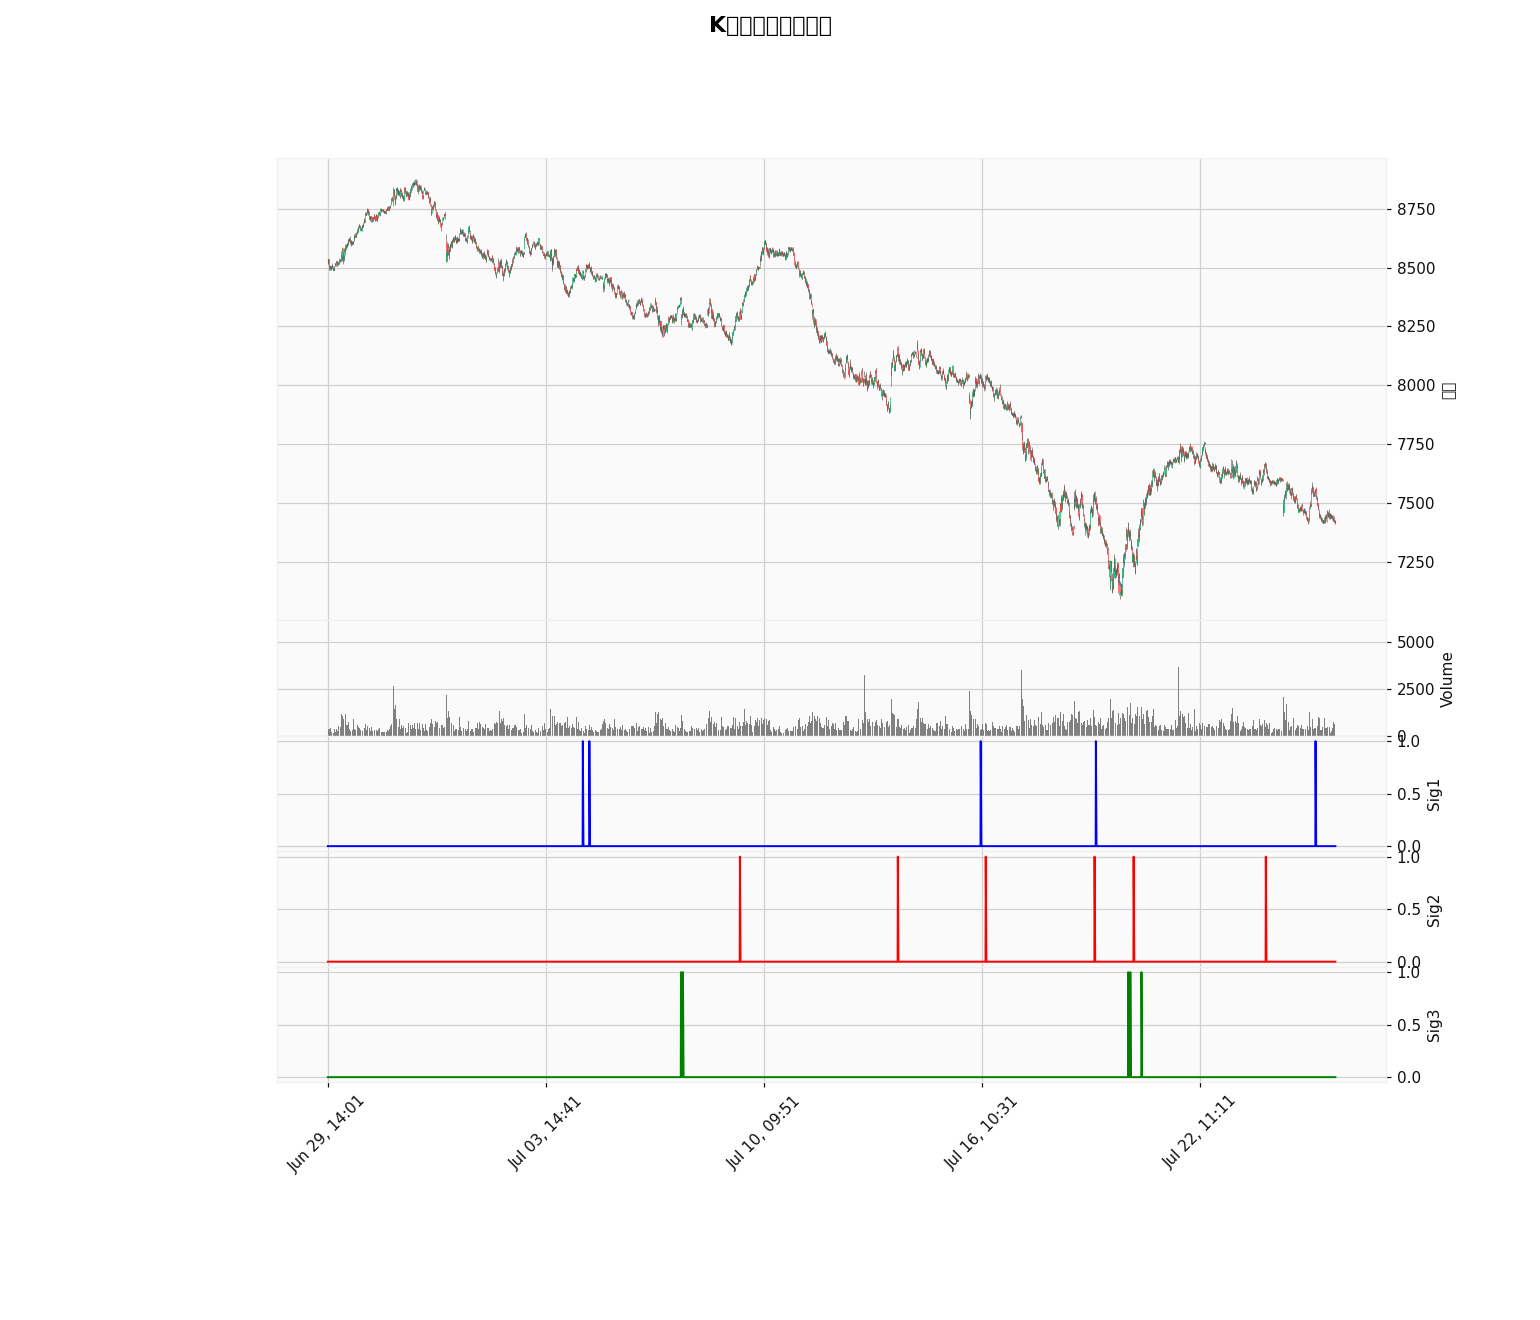

In [82]:
   
# 绘制
mpf.plot(df,
         type='candle',
         style='yahoo',
         addplot=add_plots,
         panel_ratios=(4, 1, 1, 1, 1),
         figsize=(14, 12),
         title='K线图与多指标副图',
         ylabel='价格',
         xrotation=45)


In [ ]:
plt.show()

In [71]:
# ============ 方法2: 更精细的控制 ============
def plot_custom_kline_with_indicators(df):
    """
    自定义绘制K线图和副图指标
    """
    # 创建figure和子图
    fig = plt.figure(figsize=(14, 12))
    
    # 创建网格布局：主图占3份，每个副图占1份
    gs = fig.add_gridspec(5, 1, height_ratios=[3, 1, 1, 1, 1], hspace=0.3)
    
    # 主图 - K线
    ax1 = fig.add_subplot(gs[0])
    
    # 绘制K线
    mpf.plot(df, 
             type='candle',
             style='charles',
             ax=ax1,
             volume=True,
             xrotation=45,
             ylabel='价格')
    
    ax1.set_title('K线图与信号指标', fontsize=14)
    ax1.grid(True, alpha=0.3)
    
    # 副图1 - Volume
    ax2 = fig.add_subplot(gs[1])
    colors = ['green' if df['close'].iloc[i] >= df['open'].iloc[i] else 'red' 
              for i in range(len(df))]
    ax2.bar(df.index, df['volume'], color=colors, alpha=0.7)
    ax2.set_ylabel('Volume')
    ax2.grid(True, alpha=0.3)
    
    # 副图2 - sig1
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(df.index, df['sig1'], color='blue', linewidth=1.5, label='sig1')
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax3.set_ylabel('Sig1')
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper right')
    
    # 副图3 - sig2
    ax4 = fig.add_subplot(gs[3])
    ax4.plot(df.index, df['sig2'], color='red', linewidth=1.5, label='sig2')
    ax4.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax4.set_ylabel('Sig2')
    ax4.grid(True, alpha=0.3)
    ax4.legend(loc='upper right')
    
    # 副图4 - sig3
    ax5 = fig.add_subplot(gs[4])
    ax5.plot(df.index, df['sig3'], color='green', linewidth=1.5, label='sig3')
    ax5.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax5.set_ylabel('Sig3')
    ax5.grid(True, alpha=0.3)
    ax5.legend(loc='upper right')
    ax5.set_xlabel('时间')
    
    # 自动调整日期显示
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

d:\ProgramData\Anaconda3\lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
<ipython-input-80-fb7f4d2d05b3>:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
d:\ProgramData\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Glyph 20215 (\N{CJK UNIFIED IDEOGRAPH-4EF7}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\ProgramData\Anaconda3\lib\site-packages\IPython\core\pylabtools.py:132: UserWarning: Gl

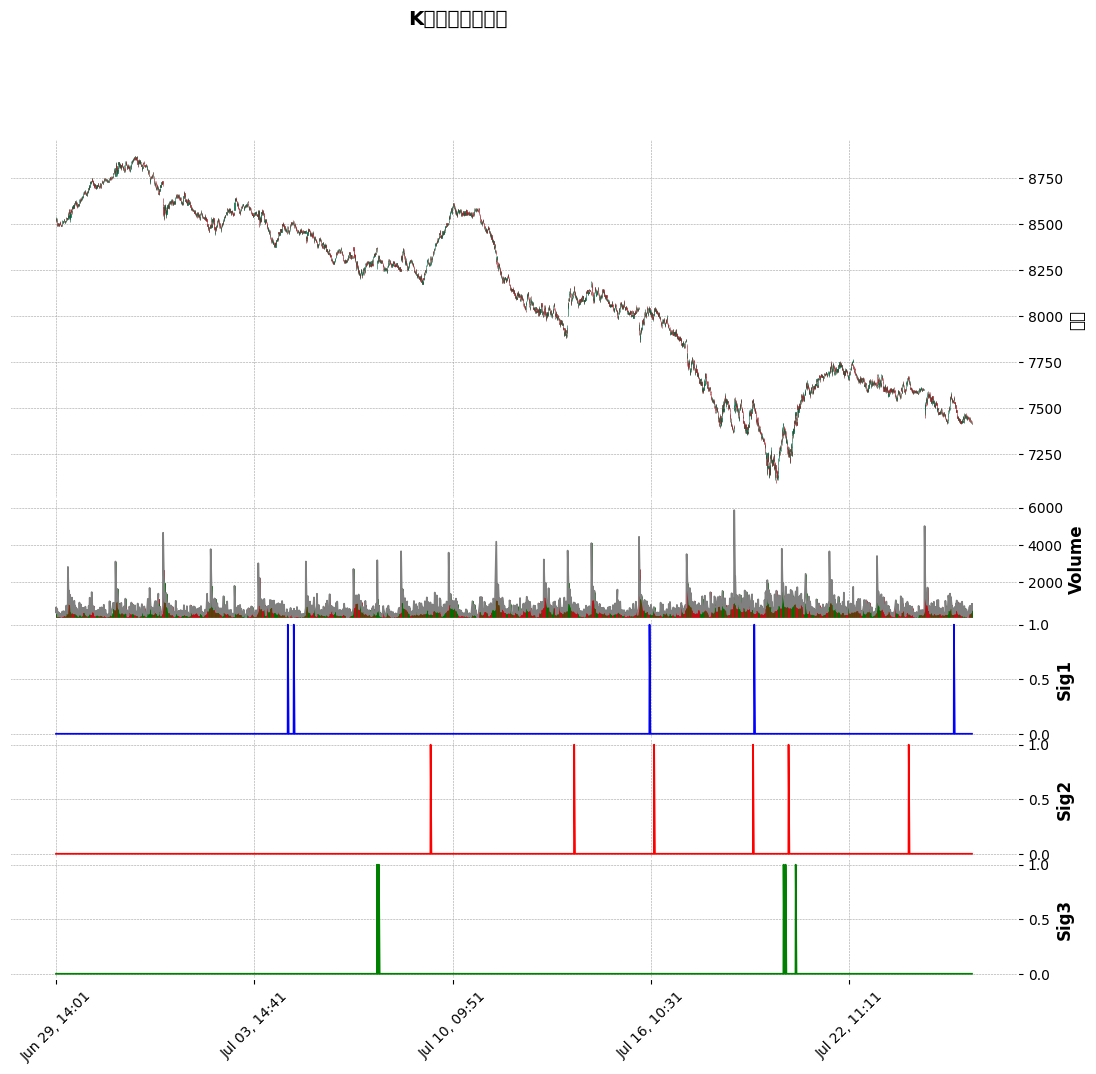

In [80]:
apds = []

# 添加volume副图
apds.append(mpf.make_addplot(df['volume'], panel=1, color='gray', ylabel='Volume'))

# 添加sig1副图
apds.append(mpf.make_addplot(df['sig1'], panel=2, color='blue', ylabel='Sig1', 
                             secondary_y=False))

# 添加sig2副图
apds.append(mpf.make_addplot(df['sig2'], panel=3, color='red', ylabel='Sig2',
                             secondary_y=False))

# 添加sig3副图
apds.append(mpf.make_addplot(df['sig3'], panel=4, color='green', ylabel='Sig3',
                             secondary_y=False))

# 绘制K线图
fig, axes = mpf.plot(df, 
                      type='candle',  # K线图类型
                      style='charles',  # 样式：charles, yahoo, binance等
                      volume=True,  # 不显示默认的volume，因为我们在副图中显示
                      addplot=apds,
                      panel_ratios=(3, 1, 1, 1, 1),  # 主图和副图的高度比例
                      figsize=(14, 12),
                      title='K线图与信号指标',
                      ylabel='价格',
                      returnfig=True)

# 调整子图间距
plt.tight_layout()
plt.show()

In [79]:
df.index.dtype

dtype('<M8[ns]')